# Project Objective

## Analytical Questions

Before beginning the analysis, the following questions will guide this project:

- What does the text corpus look like, and how large is it?
- Which words occur most frequently in the dataset?
- How should the text be preprocessed before building NLP models?
- How accurately can an n-gram model predict the next word?
- How accurately can an autocorrect algorithm correct misspelled words?
- Which autocomplete predictions are the most reliable?
- What are the precision and recall of the autocomplete and autocorrect systems?
- Which algorithm performs better overall?
- What limitations exist compared with production systems such as Google Keyboard?

## Import Libraries

## 1. Load and Inspect the Dataset

In [1]:
import os

os.getcwd()

'/Users/kenyaharvey/Desktop/enron-email-dataset'

In [2]:
import os

os.listdir()

['.DS_Store',
 'images',
 'enron_email_dataset.ipynb',
 'README.md',
 'notebook',
 'data']

In [3]:
from pathlib import Path

for item in Path().iterdir():
    print(item)

.DS_Store
images
enron_email_dataset.ipynb
README.md
notebook
data


In [4]:
import pandas as pd

emails_sample = pd.read_excel(
    "data/emails.xlsx",
    nrows=1000
)

In [5]:
emails_sample.head()

,file,message
0,allen-p/_sent_mail/1.,Message-ID: <18782981.1075855378110.JavaMail.e...
1,allen-p/_sent_mail/10.,Message-ID: <15464986.1075855378456.JavaMail.e...
2,allen-p/_sent_mail/100.,Message-ID: <24216240.1075855687451.JavaMail.e...
3,allen-p/_sent_mail/1000.,Message-ID: <13505866.1075863688222.JavaMail.e...
4,allen-p/_sent_mail/1001.,Message-ID: <30922949.1075863688243.JavaMail.e...


In [6]:
emails_sample.shape

(1000, 2)

In [7]:
emails_sample.columns.tolist()

['file', 'message']

In [8]:
from pathlib import Path

data_folder = Path("data")

for file in data_folder.iterdir():
    print(file.name)

emails.xlsx


In [9]:
from pathlib import Path

data_folder = Path("data")

for file in data_folder.iterdir():
    print(file.name)

emails.xlsx


In [10]:
import openpyxl

wb = openpyxl.load_workbook(file)
ws = wb[wb.sheetnames[0]]

print(ws.max_row)
print(ws.max_column)

1048576
1832


In [11]:
headers = next(ws.iter_rows(values_only=True))

print(headers)

('file', 'message', None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, No

In [12]:
for row in ws.iter_rows(min_row=2, max_row=4, values_only=True):
    print(row[0])
    print(row[1])
    print("-" * 80)

allen-p/_sent_mail/1.
Message-ID: <18782981.1075855378110.JavaMail.evans@thyme>
Date: Mon, 14 May 2001 16:39:00 -0700 (PDT)
From: phillip.allen@enron.com
To: tim.belden@enron.com
Subject: 
Mime-Version: 1.0
Content-Type: text/plain; charset=us-ascii
Content-Transfer-Encoding: 7bit
X-From: Phillip K Allen
X-To: Tim Belden <Tim Belden/Enron@EnronXGate>
X-cc: 
X-bcc: 
X-Folder: \Phillip_Allen_Jan2002_1\Allen, Phillip K.\'Sent Mail
X-Origin: Allen-P
X-FileName: pallen (Non-Privileged).pst

Here is our forecast

 
--------------------------------------------------------------------------------
allen-p/_sent_mail/10.
Message-ID: <15464986.1075855378456.JavaMail.evans@thyme>
Date: Fri, 4 May 2001 13:51:00 -0700 (PDT)
From: phillip.allen@enron.com
To: john.lavorato@enron.com
Subject: Re:
Mime-Version: 1.0
Content-Type: text/plain; charset=us-ascii
Content-Transfer-Encoding: 7bit
X-From: Phillip K Allen
X-To: John J Lavorato <John J Lavorato/ENRON@enronXgate@ENRON>
X-cc: 
X-bcc: 
X-Folder: \Phi

In [13]:
from openpyxl import load_workbook

In [14]:
wb = load_workbook(
    "data/emails.xlsx",
    read_only=True,
    data_only=True
)

In [15]:
ws = wb[wb.sheetnames[0]]

In [16]:
print(ws.max_row)
print(ws.max_column)

1048576
1832


In [17]:
messages = []

for row in ws.iter_rows(min_row=2, values_only=True):
    message = row[1]

    if message is not None:
        messages.append(message)

print(f"Number of messages: {len(messages):,}")

Number of messages: 357,670


## Text Corpus Summary

The Enron Email Dataset was selected as the text corpus for this project.

After inspecting the dataset, it was determined that:

- Number of email messages: **357,670**
- Primary text column: **message**
- Identifier column: **file**

This corpus contains real-world business email communications, making it suitable for building and evaluating autocomplete and autocorrect algorithms using NLP techniques.

In [18]:
print(messages[0])

Message-ID: <18782981.1075855378110.JavaMail.evans@thyme>
Date: Mon, 14 May 2001 16:39:00 -0700 (PDT)
From: phillip.allen@enron.com
To: tim.belden@enron.com
Subject: 
Mime-Version: 1.0
Content-Type: text/plain; charset=us-ascii
Content-Transfer-Encoding: 7bit
X-From: Phillip K Allen
X-To: Tim Belden <Tim Belden/Enron@EnronXGate>
X-cc: 
X-bcc: 
X-Folder: \Phillip_Allen_Jan2002_1\Allen, Phillip K.\'Sent Mail
X-Origin: Allen-P
X-FileName: pallen (Non-Privileged).pst

Here is our forecast

 


In [19]:
print(messages[1])

Message-ID: <15464986.1075855378456.JavaMail.evans@thyme>
Date: Fri, 4 May 2001 13:51:00 -0700 (PDT)
From: phillip.allen@enron.com
To: john.lavorato@enron.com
Subject: Re:
Mime-Version: 1.0
Content-Type: text/plain; charset=us-ascii
Content-Transfer-Encoding: 7bit
X-From: Phillip K Allen
X-To: John J Lavorato <John J Lavorato/ENRON@enronXgate@ENRON>
X-cc: 
X-bcc: 
X-Folder: \Phillip_Allen_Jan2002_1\Allen, Phillip K.\'Sent Mail
X-Origin: Allen-P
X-FileName: pallen (Non-Privileged).pst

Traveling to have a business meeting takes the fun out of the trip.  Especially if you have to prepare a presentation.  I would suggest holding the business plan meetings here then take a trip without any formal business meetings.  I would even try and get some honest opinions on whether a trip is even desired or necessary.

As far as the business meetings, I think it would be more productive to try and stimulate discussions across the different groups about what is working and what is not.  Too often the

## Dataset Inspection

The Enron Email Dataset contains complete email records rather than only message text.

Key observations:

- Each record includes email metadata such as **From**, **To**, **Date**, and **Subject**.
- Each record contains the actual email body.
- The emails contain real business communication, providing natural language suitable for NLP analysis.

These observations indicate that preprocessing is necessary before building autocomplete and autocorrect models. The preprocessing stage will focus on cleaning the text by removing unnecessary metadata and preparing the email content for analysis.

In [20]:
messages

["Message-ID: <18782981.1075855378110.JavaMail.evans@thyme>\nDate: Mon, 14 May 2001 16:39:00 -0700 (PDT)\nFrom: phillip.allen@enron.com\nTo: tim.belden@enron.com\nSubject: \nMime-Version: 1.0\nContent-Type: text/plain; charset=us-ascii\nContent-Transfer-Encoding: 7bit\nX-From: Phillip K Allen\nX-To: Tim Belden <Tim Belden/Enron@EnronXGate>\nX-cc: \nX-bcc: \nX-Folder: \\Phillip_Allen_Jan2002_1\\Allen, Phillip K.\\'Sent Mail\nX-Origin: Allen-P\nX-FileName: pallen (Non-Privileged).pst\n\nHere is our forecast\n\n ",
 "Message-ID: <15464986.1075855378456.JavaMail.evans@thyme>\nDate: Fri, 4 May 2001 13:51:00 -0700 (PDT)\nFrom: phillip.allen@enron.com\nTo: john.lavorato@enron.com\nSubject: Re:\nMime-Version: 1.0\nContent-Type: text/plain; charset=us-ascii\nContent-Transfer-Encoding: 7bit\nX-From: Phillip K Allen\nX-To: John J Lavorato <John J Lavorato/ENRON@enronXgate@ENRON>\nX-cc: \nX-bcc: \nX-Folder: \\Phillip_Allen_Jan2002_1\\Allen, Phillip K.\\'Sent Mail\nX-Origin: Allen-P\nX-FileName: pa

In [21]:
import pandas as pd

# Ensure emails_sample is defined before calling .head()
if 'emails_sample' not in globals():
    emails_sample = pd.read_excel("data/emails.xlsx", nrows=1000)

emails_sample.head()

,file,message
0,allen-p/_sent_mail/1.,Message-ID: <18782981.1075855378110.JavaMail.e...
1,allen-p/_sent_mail/10.,Message-ID: <15464986.1075855378456.JavaMail.e...
2,allen-p/_sent_mail/100.,Message-ID: <24216240.1075855687451.JavaMail.e...
3,allen-p/_sent_mail/1000.,Message-ID: <13505866.1075863688222.JavaMail.e...
4,allen-p/_sent_mail/1001.,Message-ID: <30922949.1075863688243.JavaMail.e...


In [22]:
emails_sample.shape

(1000, 2)

In [23]:
emails_sample.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   file     1000 non-null   str  
 1   message  1000 non-null   str  
dtypes: str(2)
memory usage: 15.8 KB


In [24]:
emails_sample.isna().sum()

file       0
message    0
dtype: int64

## Initial Data Quality Assessment: 

The dataset contains 1,000 email records and two text-based columns: file and message. There are no missing values in either column, and both columns are stored as string data types.

In [25]:
%whos

Variable        Type                 Data/Info
----------------------------------------------
Path            type                 <class 'pathlib.Path'>
data_folder     PosixPath            data
emails_sample   DataFrame            Shape: (1000, 2)
file            PosixPath            data/emails.xlsx
headers         tuple                n=1832
item            PosixPath            data
load_workbook   function             <function load_workbook at 0x14a78c5e0>
message         NoneType             None
messages        list                 n=357670
openpyxl        module               <module 'openpyxl' from '<...>es/openpyxl/__init__.py'>
os              module               <module 'os' (frozen)>
pd              module               <module 'pandas' from '/o<...>ages/pandas/__init__.py'>
row             tuple                n=1832
wb              Workbook             <openpyxl.workbook.workbo<...>ok object at 0x348329820>
ws              ReadOnlyWorksheet    <openpyxl.worksheet._read

In [26]:
emails_sample["message_length"] = emails_sample["message"].str.len()

emails_sample["message_length"].describe()

count     1000.000000
mean      1394.246000
std       1770.694845
min        434.000000
25%        572.000000
50%        817.000000
75%       1419.250000
max      16884.000000
Name: message_length, dtype: float64

## Message Length Analysis: 

Email messages range from 434 to 16,884 characters. The median message length is 817 characters, while the mean is 1,394 characters. The higher mean compared with the median suggests a right-skewed distribution caused by a smaller number of substantially longer messages.

In [27]:
emails_sample["message"].iloc[0][:500]

"Message-ID: <18782981.1075855378110.JavaMail.evans@thyme>\nDate: Mon, 14 May 2001 16:39:00 -0700 (PDT)\nFrom: phillip.allen@enron.com\nTo: tim.belden@enron.com\nSubject: \nMime-Version: 1.0\nContent-Type: text/plain; charset=us-ascii\nContent-Transfer-Encoding: 7bit\nX-From: Phillip K Allen\nX-To: Tim Belden <Tim Belden/Enron@EnronXGate>\nX-cc: \nX-bcc: \nX-Folder: \\Phillip_Allen_Jan2002_1\\Allen, Phillip K.\\'Sent Mail\nX-Origin: Allen-P\nX-FileName: pallen (Non-Privileged).pst\n\nHere is our forecast\n\n "

In [28]:
emails_sample["email_body"] = emails_sample["message"].str.split("\n\n", n=1).str[-1].str.strip()

In [29]:
emails_sample[["file", "email_body"]].head()

,file,email_body
0,allen-p/_sent_mail/1.,Here is our forecast
1,allen-p/_sent_mail/10.,Traveling to have a business meeting takes the...
2,allen-p/_sent_mail/100.,test successful. way to go!!!
3,allen-p/_sent_mail/1000.,"Randy,\n\n Can you send me a schedule of the s..."
4,allen-p/_sent_mail/1001.,Let's shoot for Tuesday at 11:45.


In [30]:
emails_sample["email_body"].str.strip().eq("").sum()

np.int64(0)

In [31]:
emails_sample["email_body"].duplicated().sum()

np.int64(344)

In [32]:
emails_sample["email_body"].nunique()

656

In [33]:
df = emails_sample
df.head()

,file,message,message_length,email_body
0,allen-p/_sent_mail/1.,Message-ID: <18782981.1075855378110.JavaMail.e...,492,Here is our forecast
1,allen-p/_sent_mail/10.,Message-ID: <15464986.1075855378456.JavaMail.e...,1276,Traveling to have a business meeting takes the...
2,allen-p/_sent_mail/100.,Message-ID: <24216240.1075855687451.JavaMail.e...,462,test successful. way to go!!!
3,allen-p/_sent_mail/1000.,Message-ID: <13505866.1075863688222.JavaMail.e...,607,"Randy,\n\n Can you send me a schedule of the s..."
4,allen-p/_sent_mail/1001.,Message-ID: <30922949.1075863688243.JavaMail.e...,460,Let's shoot for Tuesday at 11:45.


In [34]:
emails_sample["message_length"] = emails_sample["message"].str.len()

emails_sample["message_length"].describe()

count     1000.000000
mean      1394.246000
std       1770.694845
min        434.000000
25%        572.000000
50%        817.000000
75%       1419.250000
max      16884.000000
Name: message_length, dtype: float64

In [35]:
emails_sample["email_body"].str.len().describe()

count     1000.000000
mean       922.045000
std       1755.136025
min          2.000000
25%        119.000000
50%        365.000000
75%        924.250000
max      16395.000000
Name: email_body, dtype: float64

In [36]:
emails_sample["email_body_length"] = emails_sample["email_body"].str.len()
emails_sample.nsmallest(10, "email_body_length")[["file", "email_body"]]

,file,email_body
160,allen-p/_sent_mail/239.,no
753,allen-p/all_documents/238.,no
143,allen-p/_sent_mail/223.,testing
736,allen-p/all_documents/222.,testing
353,allen-p/_sent_mail/420.,no problem
432,allen-p/_sent_mail/492.,yes please
506,allen-p/_sent_mail/559.,need help.
572,allen-p/_sent_mail/735.,raincheck?
972,allen-p/all_documents/437.,no problem
195,allen-p/_sent_mail/270.,2000-1969=31


## Short Email Check: 

The shortest email bodies were manually reviewed. Although some messages contain only a few words, they represent legitimate email content rather than missing or corrupted data. Therefore, short messages were retained for analysis.

In [37]:
emails_sample["clean_text"] = (
    emails_sample["email_body"]
    .str.lower()
    .str.replace(r"[^\w\s]", "", regex=True)
    .str.strip()
)


In [38]:
emails_sample[["email_body", "clean_text"]].head()

,email_body,clean_text
0,Here is our forecast,here is our forecast
1,Traveling to have a business meeting takes the...,traveling to have a business meeting takes the...
2,test successful. way to go!!!,test successful way to go
3,"Randy,\n\n Can you send me a schedule of the s...",randy\n\n can you send me a schedule of the sa...
4,Let's shoot for Tuesday at 11:45.,lets shoot for tuesday at 1145


In [39]:
emails_sample[["email_body", "clean_text"]].head(10)

,email_body,clean_text
0,Here is our forecast,here is our forecast
1,Traveling to have a business meeting takes the...,traveling to have a business meeting takes the...
2,test successful. way to go!!!,test successful way to go
3,"Randy,\n\n Can you send me a schedule of the s...",randy\n\n can you send me a schedule of the sa...
4,Let's shoot for Tuesday at 11:45.,lets shoot for tuesday at 1145
5,"Greg,\n\n How about either next Tuesday or Thu...",greg\n\n how about either next tuesday or thur...
6,Please cc the following distribution list with...,please cc the following distribution list with...
7,any morning between 10 and 11:30,any morning between 10 and 1130
8,1. login: pallen pw: ke9davis\n\n I don't thi...,1 login pallen pw ke9davis\n\n i dont think t...
9,---------------------- Forwarded by Phillip K ...,forwarded by phillip k allenhouect on 10162000...


In [40]:
emails_sample["clean_text"] = (
    emails_sample["clean_text"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

In [41]:
emails_sample[["email_body", "clean_text"]].head(10)

,email_body,clean_text
0,Here is our forecast,here is our forecast
1,Traveling to have a business meeting takes the...,traveling to have a business meeting takes the...
2,test successful. way to go!!!,test successful way to go
3,"Randy,\n\n Can you send me a schedule of the s...",randy can you send me a schedule of the salary...
4,Let's shoot for Tuesday at 11:45.,lets shoot for tuesday at 1145
5,"Greg,\n\n How about either next Tuesday or Thu...",greg how about either next tuesday or thursday...
6,Please cc the following distribution list with...,please cc the following distribution list with...
7,any morning between 10 and 11:30,any morning between 10 and 1130
8,1. login: pallen pw: ke9davis\n\n I don't thi...,1 login pallen pw ke9davis i dont think these ...
9,---------------------- Forwarded by Phillip K ...,forwarded by phillip k allenhouect on 10162000...


In [42]:
emails_sample["tokens"] = emails_sample["clean_text"].str.split()

In [43]:
emails_sample[["clean_text", "tokens"]].head()

,clean_text,tokens
0,here is our forecast,"[here, is, our, forecast]"
1,traveling to have a business meeting takes the...,"[traveling, to, have, a, business, meeting, ta..."
2,test successful way to go,"[test, successful, way, to, go]"
3,randy can you send me a schedule of the salary...,"[randy, can, you, send, me, a, schedule, of, t..."
4,lets shoot for tuesday at 1145,"[lets, shoot, for, tuesday, at, 1145]"


In [44]:
from collections import Counter

all_tokens = [token for tokens in emails_sample["tokens"] for token in tokens]

word_counts = Counter(all_tokens)

word_counts.most_common(20)

[('the', 5650),
 ('to', 4098),
 ('and', 2148),
 ('a', 2004),
 ('of', 1909),
 ('on', 1680),
 ('you', 1579),
 ('i', 1537),
 ('for', 1515),
 ('in', 1423),
 ('is', 1411),
 ('phillip', 1239),
 ('this', 947),
 ('that', 900),
 ('be', 871),
 ('have', 843),
 ('are', 812),
 ('by', 791),
 ('will', 746),
 ('as', 711)]

In [45]:
from collections import Counter

bigrams = [
    (tokens[i], tokens[i + 1])
    for tokens in emails_sample["tokens"]
    for i in range(len(tokens) - 1)
]

bigram_counts = Counter(bigrams)

bigram_counts.most_common(20)

[(('phillip', 'k'), 630),
 (('of', 'the'), 518),
 (('in', 'the'), 514),
 (('forwarded', 'by'), 415),
 (('k', 'allenhouect'), 366),
 (('by', 'phillip'), 350),
 (('allenhouect', 'on'), 349),
 (('09', '09'), 337),
 (('on', 'the'), 312),
 (('to', 'the'), 278),
 (('cc', 'subject'), 270),
 (('for', 'the'), 270),
 (('will', 'be'), 241),
 (('k', 'allenhouectect'), 220),
 (('you', 'have'), 217),
 (('if', 'you'), 207),
 (('i', 'am'), 195),
 (('am', 'to'), 183),
 (('is', 'a'), 182),
 (('pm', 'to'), 181)]

In [46]:
forwarded_count = emails_sample["clean_text"].str.contains(
    r"forwarded by|original message|from:|sent:|to:|subject:",
    regex=True,
    na=False
).sum()

forwarded_count

np.int64(335)

In [47]:
emails_sample["has_forwarded_header"] = emails_sample["clean_text"].str.contains(
    r"forwarded by|original message|from:|sent:|to:|subject:",
    regex=True,
    na=False
)

In [48]:
emails_sample["has_forwarded_header"].value_counts()

has_forwarded_header
False    665
True     335
Name: count, dtype: int64

## Forwarded Email Check: 

335 of 1,000 sampled emails (33.5%) contained patterns associated with forwarded-message headers. Rather than deleting these records, they were flagged for further analysis to avoid unnecessarily removing potentially useful text.

In [49]:
emails_sample.groupby("has_forwarded_header")["message_length"].describe()

,count,mean,std,min,25%,50%,75%,max
has_forwarded_header,,,,,,,,
False,665.0,944.440602,1233.922957,434.0,532.0,638.0,919.0,16884.0
True,335.0,2287.143284,2269.038628,615.0,1054.5,1505.0,2372.0,15727.0


## Finding: 

Emails containing forwarded-message/header patterns were substantially longer than emails without detected headers. The median message length was 1,505 characters for flagged emails compared with 638 characters for unflagged emails. This suggests that forwarded content contributes considerable additional text and may influence NLP frequency patterns.

In [50]:
emails_sample.groupby("has_forwarded_header")["email_body_length"].describe()

,count,mean,std,min,25%,50%,75%,max
has_forwarded_header,,,,,,,,
False,665.0,472.145865,1211.795951,2.0,81.0,174.0,440.0,16395.0
True,335.0,1815.128358,2256.443942,182.0,579.0,1052.0,1920.0,15270.0


In [51]:
%pip install -q nltk

import nltk
from nltk.corpus import stopwords

nltk.download("stopwords", quiet=True)

stop_words = set(stopwords.words("english"))

df["tokens_no_stopwords"] = df["tokens"].apply(
    lambda tokens: [word for word in (tokens or []) if word not in stop_words]
)

df[["clean_text", "tokens_no_stopwords"]].head()

Note: you may need to restart the kernel to use updated packages.


,clean_text,tokens_no_stopwords
0,here is our forecast,[forecast]
1,traveling to have a business meeting takes the...,"[traveling, business, meeting, takes, fun, tri..."
2,test successful way to go,"[test, successful, way, go]"
3,randy can you send me a schedule of the salary...,"[randy, send, schedule, salary, level, everyon..."
4,lets shoot for tuesday at 1145,"[lets, shoot, tuesday, 1145]"


In [52]:
from collections import Counter

word_counts_no_stopwords = Counter(
    word
    for tokens in df["tokens_no_stopwords"]
    for word in tokens
)

word_counts_no_stopwords.most_common(20)

[('phillip', 1239),
 ('k', 640),
 ('pm', 564),
 ('would', 455),
 ('subject', 453),
 ('09', 436),
 ('please', 420),
 ('cc', 419),
 ('forwarded', 419),
 ('gas', 403),
 ('allenhouect', 366),
 ('email', 323),
 ('power', 288),
 ('need', 262),
 ('get', 234),
 ('new', 232),
 ('allenhouectect', 228),
 ('call', 219),
 ('project', 203),
 ('meeting', 202)]

In [53]:
email_noise = {
    "phillip",
    "k",
    "allenhouect",
    "allenhouectect",
    "subject",
    "forwarded",
    "cc",
    "pm"
}

df["tokens_clean"] = df["tokens_no_stopwords"].apply(
    lambda tokens: [
        word for word in tokens
        if word not in email_noise
    ]
)

In [54]:
word_counts_clean = Counter(
    word
    for tokens in df["tokens_clean"]
    for word in tokens
)

word_counts_clean.most_common(20)

[('would', 455),
 ('09', 436),
 ('please', 420),
 ('gas', 403),
 ('email', 323),
 ('power', 288),
 ('need', 262),
 ('get', 234),
 ('new', 232),
 ('call', 219),
 ('project', 203),
 ('meeting', 202),
 ('time', 197),
 ('allen', 192),
 ('loan', 191),
 ('know', 181),
 ('also', 179),
 ('market', 176),
 ('like', 175),
 ('price', 169)]

In [55]:
email_noise.update({"09"})

df["tokens_clean"] = df["tokens_no_stopwords"].apply(
    lambda tokens: [
        word for word in tokens
        if word not in email_noise
    ]
)

word_counts_clean = Counter(
    word
    for tokens in df["tokens_clean"]
    for word in tokens
)

word_counts_clean.most_common(20)

[('would', 455),
 ('please', 420),
 ('gas', 403),
 ('email', 323),
 ('power', 288),
 ('need', 262),
 ('get', 234),
 ('new', 232),
 ('call', 219),
 ('project', 203),
 ('meeting', 202),
 ('time', 197),
 ('allen', 192),
 ('loan', 191),
 ('know', 181),
 ('also', 179),
 ('market', 176),
 ('like', 175),
 ('price', 169),
 ('john', 161)]

In [56]:
from collections import Counter

bigram_counts_clean = Counter(
    (tokens[i], tokens[i+1])
    for tokens in df["tokens_clean"]
    for i in range(len(tokens) - 1)
)

bigram_counts_clean.most_common(20)

[(('let', 'know'), 91),
 (('09image', '09image'), 87),
 (('would', 'like'), 73),
 (('natural', 'gas'), 50),
 (('west', 'desk'), 47),
 (('please', 'respond'), 43),
 (('tim', 'beldenhouectect'), 43),
 (('image', 'image'), 40),
 (('larry', 'lewter'), 37),
 (('hunter', 'shivelyhouectect'), 37),
 (('sr', 'specialist'), 37),
 (('san', 'marcos'), 36),
 (('san', 'juan'), 36),
 (('per', 'lot'), 35),
 (('position', 'manager'), 34),
 (('gas', 'daily'), 34),
 (('gas', 'prices'), 34),
 (('north', 'america'), 32),
 (('get', 'back'), 32),
 (('traders', 'said'), 32)]

In [57]:
email_noise.update({
    "09image",
    "image",
    "tim",
    "beldenhouectect"
})

df["tokens_clean"] = df["tokens_no_stopwords"].apply(
    lambda tokens: [
        word for word in tokens
        if word not in email_noise
    ]
)

In [58]:
bigram_counts_clean = Counter(
    (tokens[i], tokens[i+1])
    for tokens in df["tokens_clean"]
    for i in range(len(tokens) - 1)
)

bigram_counts_clean.most_common(20)

[(('let', 'know'), 91),
 (('would', 'like'), 73),
 (('natural', 'gas'), 50),
 (('west', 'desk'), 47),
 (('please', 'respond'), 43),
 (('larry', 'lewter'), 37),
 (('hunter', 'shivelyhouectect'), 37),
 (('sr', 'specialist'), 37),
 (('san', 'marcos'), 36),
 (('san', 'juan'), 36),
 (('per', 'lot'), 35),
 (('position', 'manager'), 34),
 (('gas', 'daily'), 34),
 (('gas', 'prices'), 34),
 (('north', 'america'), 32),
 (('get', 'back'), 32),
 (('traders', 'said'), 32),
 (('enron', 'north'), 31),
 (('america', 'corp'), 31),
 (('creekside', 'builders'), 31)]

In [59]:
from collections import Counter

word_frequency = Counter(
    word
    for tokens in df["tokens_clean"]
    for word in tokens
)

word_frequency.most_common(20)

[('would', 455),
 ('please', 420),
 ('gas', 403),
 ('email', 323),
 ('power', 288),
 ('need', 262),
 ('get', 234),
 ('new', 232),
 ('call', 219),
 ('project', 203),
 ('meeting', 202),
 ('time', 197),
 ('allen', 192),
 ('loan', 191),
 ('know', 181),
 ('also', 179),
 ('market', 176),
 ('like', 175),
 ('price', 169),
 ('john', 161)]

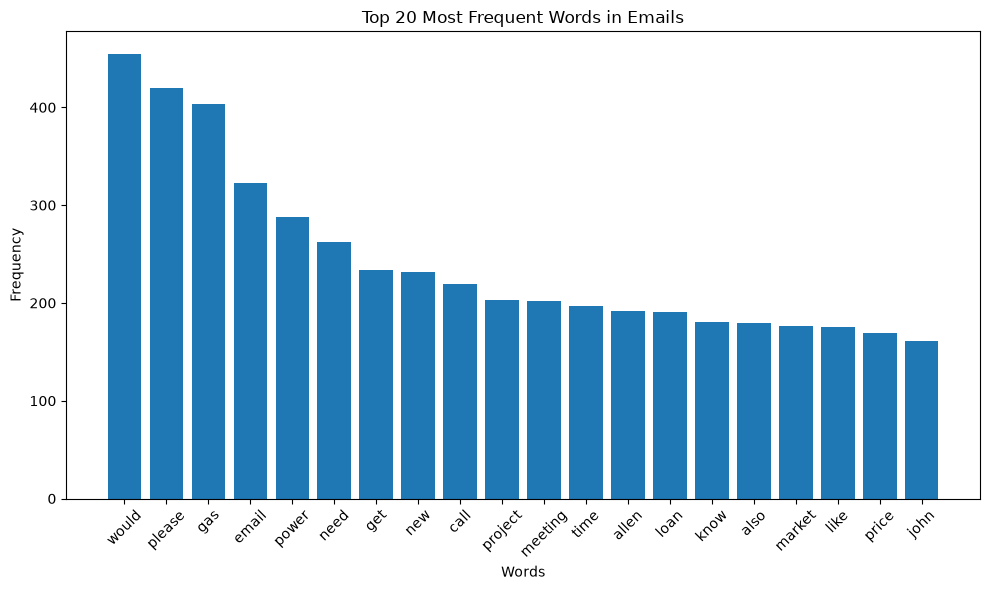

In [60]:
import matplotlib.pyplot as plt

top_words = word_frequency.most_common(20)

words = [word for word, count in top_words]
counts = [count for word, count in top_words]

plt.figure(figsize=(10, 6))
plt.bar(words, counts)

plt.title("Top 20 Most Frequent Words in Emails")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [61]:
from collections import Counter

next_word_pairs = []

for tokens in emails_sample["tokens_no_stopwords"]:
    for i in range(len(tokens) - 1):
        next_word_pairs.append((tokens[i], tokens[i + 1]))

next_word_freq = Counter(next_word_pairs)

next_word_freq.most_common(20)

[(('phillip', 'k'), 630),
 (('k', 'allenhouect'), 366),
 (('forwarded', 'phillip'), 349),
 (('09', '09'), 337),
 (('cc', 'subject'), 270),
 (('k', 'allenhouectect'), 220),
 (('phillip', 'allen'), 130),
 (('allenhouectect', 'cc'), 124),
 (('let', 'know'), 91),
 (('would', 'like'), 73),
 (('pm', 'phillip'), 65),
 (('09', '09image'), 56),
 (('09image', '09'), 56),
 (('natural', 'gas'), 50),
 (('pallenenroncom', 'cc'), 47),
 (('west', 'desk'), 47),
 (('phillipkallenenroncom', 'cc'), 46),
 (('please', 'respond'), 43),
 (('tim', 'beldenhouectect'), 43),
 (('image', 'image'), 40)]

In [62]:
common_bigrams = [
    (pair, count)
    for pair, count in next_word_freq.most_common(100)
    if all(word.isalpha() for word in pair)
]

common_bigrams[:20]

[(('phillip', 'k'), 630),
 (('k', 'allenhouect'), 366),
 (('forwarded', 'phillip'), 349),
 (('cc', 'subject'), 270),
 (('k', 'allenhouectect'), 220),
 (('phillip', 'allen'), 130),
 (('allenhouectect', 'cc'), 124),
 (('let', 'know'), 91),
 (('would', 'like'), 73),
 (('pm', 'phillip'), 65),
 (('natural', 'gas'), 50),
 (('pallenenroncom', 'cc'), 47),
 (('west', 'desk'), 47),
 (('phillipkallenenroncom', 'cc'), 46),
 (('please', 'respond'), 43),
 (('tim', 'beldenhouectect'), 43),
 (('image', 'image'), 40),
 (('k', 'allen'), 39),
 (('thank', 'phillip'), 37),
 (('larry', 'lewter'), 37)]

In [63]:
stop_terms = {
    "phillip", "k", "allen", "forwarded", "cc", "subject",
    "pm", "image", "email", "allenhouect", "allenhouectect",
    "pallenenroncom", "phillipkallenenroncom",
    "tim", "beldenhouectect", "larry", "lewter"
}

clean_bigrams = [
    (pair, count)
    for pair, count in next_word_freq.most_common(200)
    if not any(word in stop_terms for word in pair)
]

clean_bigrams[:20]

[(('09', '09'), 337),
 (('let', 'know'), 91),
 (('would', 'like'), 73),
 (('09', '09image'), 56),
 (('09image', '09'), 56),
 (('natural', 'gas'), 50),
 (('west', 'desk'), 47),
 (('please', 'respond'), 43),
 (('09image', '09image'), 38),
 (('hunter', 'shivelyhouectect'), 37),
 (('sr', 'specialist'), 37),
 (('san', 'marcos'), 36),
 (('san', 'juan'), 36),
 (('per', 'lot'), 35),
 (('position', 'manager'), 34),
 (('gas', 'daily'), 34),
 (('gas', 'prices'), 34),
 (('north', 'america'), 32),
 (('get', 'back'), 32),
 (('traders', 'said'), 32)]

In [64]:
clean_bigrams_final = [
    (pair, count)
    for pair, count in next_word_freq.most_common(500)
    if all(word.isalpha() for word in pair)
    and not any(word in stop_terms for word in pair)
]

clean_bigrams_final[:20]

[(('let', 'know'), 91),
 (('would', 'like'), 73),
 (('natural', 'gas'), 50),
 (('west', 'desk'), 47),
 (('please', 'respond'), 43),
 (('hunter', 'shivelyhouectect'), 37),
 (('sr', 'specialist'), 37),
 (('san', 'marcos'), 36),
 (('san', 'juan'), 36),
 (('per', 'lot'), 35),
 (('position', 'manager'), 34),
 (('gas', 'daily'), 34),
 (('gas', 'prices'), 34),
 (('north', 'america'), 32),
 (('get', 'back'), 32),
 (('traders', 'said'), 32),
 (('enron', 'north'), 31),
 (('america', 'corp'), 31),
 (('creekside', 'builders'), 31),
 (('george', 'richards'), 30)]

In [65]:
# Create a DataFrame from the bigram frequencies (use the existing Counter `bigram_counts`)
bigram_freq = bigram_counts.most_common()
bigram_df = pd.DataFrame(bigram_freq, columns=["bigram", "frequency"])

bigram_df.head(20)

,bigram,frequency
0,"(phillip, k)",630
1,"(of, the)",518
2,"(in, the)",514
3,"(forwarded, by)",415
4,"(k, allenhouect)",366
5,"(by, phillip)",350
6,"(allenhouect, on)",349
7,"(09, 09)",337
8,"(on, the)",312
9,"(to, the)",278


In [66]:
# Show the 20 most common bigrams
bigram_df.head(20)

,bigram,frequency
0,"(phillip, k)",630
1,"(of, the)",518
2,"(in, the)",514
3,"(forwarded, by)",415
4,"(k, allenhouect)",366
5,"(by, phillip)",350
6,"(allenhouect, on)",349
7,"(09, 09)",337
8,"(on, the)",312
9,"(to, the)",278


In [67]:
from collections import Counter

# Create a fresh list of bigrams using tokens with stopwords removed
all_bigrams_clean = []

for tokens in emails_sample["tokens_no_stopwords"]:
    for i in range(len(tokens) - 1):
        all_bigrams_clean.append((tokens[i], tokens[i + 1]))

# Count the cleaned bigrams
clean_bigram_freq = Counter(all_bigrams_clean)

# Create a DataFrame
clean_bigram_df = pd.DataFrame(
    clean_bigram_freq.items(),
    columns=["bigram", "frequency"]
)

# Sort by frequency
clean_bigram_df = clean_bigram_df.sort_values(
    "frequency",
    ascending=False
).reset_index(drop=True)

# Display the top 20
clean_bigram_df.head(20)

,bigram,frequency
0,"(phillip, k)",630
1,"(k, allenhouect)",366
2,"(forwarded, phillip)",349
3,"(09, 09)",337
4,"(cc, subject)",270
5,"(k, allenhouectect)",220
6,"(phillip, allen)",130
7,"(allenhouectect, cc)",124
8,"(let, know)",91
9,"(would, like)",73


In [68]:
# Create an autocomplete lookup dictionary

autocomplete = {}

for (word1, word2), frequency in clean_bigram_freq.items():
    if word1 not in autocomplete:
        autocomplete[word1] = []
    
    autocomplete[word1].append((word2, frequency))

# Sort each prediction by frequency
for word in autocomplete:
    autocomplete[word] = sorted(
        autocomplete[word],
        key=lambda x: x[1],
        reverse=True
    )

# Test a few words
for word in ["let", "would", "natural", "please", "gas"]:
    print(f"{word} -> {autocomplete.get(word, [])[:5]}")

let -> [('know', 91), ('christi', 4), ('tenants', 2), ('decide', 2), ('deposit', 2)]
would -> [('like', 73), ('also', 15), ('likely', 10), ('mean', 9), ('want', 8)]
natural -> [('gas', 50), ('ga', 2)]
please -> [('respond', 43), ('call', 26), ('list', 19), ('click', 19), ('contact', 18)]
gas -> [('daily', 34), ('prices', 34), ('power', 27), ('trading', 21), ('price', 19)]


In [69]:
from collections import Counter

trigrams = []

for tokens in emails_sample["tokens_no_stopwords"]:
    trigrams.extend(
        zip(tokens, tokens[1:], tokens[2:])
    )

trigram_counts = Counter(trigrams)

trigram_counts.most_common(20)

[(('phillip', 'k', 'allenhouect'), 366),
 (('forwarded', 'phillip', 'k'), 349),
 (('09', '09', '09'), 267),
 (('phillip', 'k', 'allenhouectect'), 219),
 (('k', 'allenhouectect', 'cc'), 122),
 (('allenhouectect', 'cc', 'subject'), 76),
 (('pm', 'phillip', 'k'), 64),
 (('09image', '09', '09'), 53),
 (('09', '09', '09image'), 52),
 (('phillipkallenenroncom', 'cc', 'subject'), 40),
 (('phillip', 'k', 'allen'), 39),
 (('image', 'image', 'image'), 36),
 (('09', '09image', '09'), 33),
 (('enron', 'north', 'america'), 31),
 (('north', 'america', 'corp'), 31),
 (('phillip', 'forwarded', 'phillip'), 30),
 (('phillip', 'allen', 'pallenenroncom'), 29),
 (('creekside', 'builders', 'llc'), 29),
 (('pallenenroncom', 'cc', 'subject'), 28),
 (('george', 'richards', 'cbpresaustinrrcom'), 24)]

In [70]:
# Remove common email/data artifacts
email_noise = {
    "09",
    "image",
    "09image"
}

clean_trigrams = []

for tokens in emails_sample["tokens_no_stopwords"]:
    filtered_tokens = [
        token for token in tokens
        if token not in email_noise
        and "houect" not in token
        and "enroncom" not in token
    ]
    
    clean_trigrams.extend(
        zip(filtered_tokens, filtered_tokens[1:], filtered_tokens[2:])
    )

clean_trigram_counts = Counter(clean_trigrams)

clean_trigram_counts.most_common(20)

[(('forwarded', 'phillip', 'k'), 349),
 (('phillip', 'k', 'cc'), 122),
 (('k', 'cc', 'subject'), 76),
 (('pm', 'phillip', 'k'), 64),
 (('pm', 'cc', 'subject'), 39),
 (('phillip', 'k', 'allen'), 39),
 (('enron', 'north', 'america'), 31),
 (('north', 'america', 'corp'), 31),
 (('phillip', 'forwarded', 'phillip'), 30),
 (('creekside', 'builders', 'llc'), 29),
 (('hunter', 'phillip', 'k'), 28),
 (('george', 'richards', 'cbpresaustinrrcom'), 24),
 (('phillip', 'k', '09262000'), 24),
 (('sr', 'specialist', 'east'), 24),
 (('specialist', 'east', 'basis'), 24),
 (('please', 'respond', 'cbpresaustinrrcom'), 23),
 (('cc', 'larry', 'lewter'), 23),
 (('respond', 'cbpresaustinrrcom', 'phillip'), 22),
 (('cbpresaustinrrcom', 'phillip', 'allen'), 22),
 (('pm', 'george', 'richards'), 21)]

In [71]:
# Create trigrams from the cleaned email body
body_trigrams = []

for tokens in emails_sample["tokens_no_stopwords"]:
    body_trigrams.extend(
        zip(tokens, tokens[1:], tokens[2:])
    )

body_trigram_counts = Counter(body_trigrams)

body_trigram_counts.most_common(20)

[(('phillip', 'k', 'allenhouect'), 366),
 (('forwarded', 'phillip', 'k'), 349),
 (('09', '09', '09'), 267),
 (('phillip', 'k', 'allenhouectect'), 219),
 (('k', 'allenhouectect', 'cc'), 122),
 (('allenhouectect', 'cc', 'subject'), 76),
 (('pm', 'phillip', 'k'), 64),
 (('09image', '09', '09'), 53),
 (('09', '09', '09image'), 52),
 (('phillipkallenenroncom', 'cc', 'subject'), 40),
 (('phillip', 'k', 'allen'), 39),
 (('image', 'image', 'image'), 36),
 (('09', '09image', '09'), 33),
 (('enron', 'north', 'america'), 31),
 (('north', 'america', 'corp'), 31),
 (('phillip', 'forwarded', 'phillip'), 30),
 (('phillip', 'allen', 'pallenenroncom'), 29),
 (('creekside', 'builders', 'llc'), 29),
 (('pallenenroncom', 'cc', 'subject'), 28),
 (('george', 'richards', 'cbpresaustinrrcom'), 24)]

In [72]:
import re

def tokenize_body(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    tokens = text.split()
    return tokens

emails_sample["body_tokens"] = emails_sample["email_body"].apply(tokenize_body)

emails_sample[["email_body", "body_tokens"]].head()

,email_body,body_tokens
0,Here is our forecast,"[here, is, our, forecast]"
1,Traveling to have a business meeting takes the...,"[traveling, to, have, a, business, meeting, ta..."
2,test successful. way to go!!!,"[test, successful, way, to, go]"
3,"Randy,\n\n Can you send me a schedule of the s...","[randy, can, you, send, me, a, schedule, of, t..."
4,Let's shoot for Tuesday at 11:45.,"[let, s, shoot, for, tuesday, at]"


In [73]:
emails_sample["body_tokens_no_stopwords"] = emails_sample["body_tokens"].apply(
    lambda tokens: [word for word in tokens if word not in stop_words]
)

emails_sample[["email_body", "body_tokens_no_stopwords"]].head()

,email_body,body_tokens_no_stopwords
0,Here is our forecast,[forecast]
1,Traveling to have a business meeting takes the...,"[traveling, business, meeting, takes, fun, tri..."
2,test successful. way to go!!!,"[test, successful, way, go]"
3,"Randy,\n\n Can you send me a schedule of the s...","[randy, send, schedule, salary, level, everyon..."
4,Let's shoot for Tuesday at 11:45.,"[let, shoot, tuesday]"


In [74]:
body_trigrams = []

for tokens in emails_sample["body_tokens_no_stopwords"]:
    body_trigrams.extend(
        zip(tokens, tokens[1:], tokens[2:])
    )

body_trigram_counts = Counter(body_trigrams)

body_trigram_counts.most_common(20)

[(('hou', 'ect', 'ect'), 1844),
 (('phillip', 'k', 'allen'), 717),
 (('allen', 'hou', 'ect'), 594),
 (('k', 'allen', 'hou'), 588),
 (('corp', 'enron', 'enron'), 533),
 (('na', 'enron', 'enron'), 530),
 (('forwarded', 'phillip', 'k'), 349),
 (('hou', 'ect', 'pm'), 232),
 (('ect', 'ect', 'cc'), 219),
 (('hou', 'ees', 'ees'), 217),
 (('pdx', 'ect', 'ect'), 160),
 (('ect', 'cc', 'subject'), 135),
 (('hr', 'corp', 'enron'), 135),
 (('image', 'image', 'image'), 125),
 (('enron', 'com', 'cc'), 119),
 (('com', 'cc', 'subject'), 104),
 (('pallen', 'enron', 'com'), 87),
 (('k', 'allen', 'enron'), 87),
 (('allen', 'enron', 'com'), 87),
 (('ect', 'phillip', 'k'), 84)]

In [75]:
# Remove obvious email artifacts and very short tokens
def clean_body_tokens(tokens):
    cleaned = []

    for token in tokens:
        if len(token) < 2:
            continue

        if token in {"hou", "ect", "ees", "pdx", "na", "hr"}:
            continue

        if token in {"image", "forwarded", "cc", "subject"}:
            continue

        cleaned.append(token)

    return cleaned


emails_sample["final_body_tokens"] = (
    emails_sample["body_tokens_no_stopwords"]
    .apply(clean_body_tokens)
)

emails_sample[["email_body", "final_body_tokens"]].head()

,email_body,final_body_tokens
0,Here is our forecast,[forecast]
1,Traveling to have a business meeting takes the...,"[traveling, business, meeting, takes, fun, tri..."
2,test successful. way to go!!!,"[test, successful, way, go]"
3,"Randy,\n\n Can you send me a schedule of the s...","[randy, send, schedule, salary, level, everyon..."
4,Let's shoot for Tuesday at 11:45.,"[let, shoot, tuesday]"


In [76]:
body_trigrams = []

for tokens in emails_sample["final_body_tokens"]:
    body_trigrams.extend(
        zip(tokens, tokens[1:], tokens[2:])
    )

final_trigram_counts = Counter(body_trigrams)

final_trigram_counts.most_common(20)

[(('corp', 'enron', 'enron'), 533),
 (('phillip', 'allen', 'pm'), 230),
 (('phillip', 'allen', 'enron'), 101),
 (('pallen', 'enron', 'com'), 88),
 (('allen', 'enron', 'com'), 87),
 (('pm', 'phillip', 'allen'), 78),
 (('austin', 'rr', 'com'), 62),
 (('com', 'phillip', 'allen'), 53),
 (('cbpres', 'austin', 'rr'), 51),
 (('enron', 'development', 'enron'), 48),
 (('development', 'enron', 'development'), 48),
 (('hunter', 'shively', 'phillip'), 46),
 (('shively', 'phillip', 'allen'), 46),
 (('james', 'steffes', 'enron'), 43),
 (('http', 'www', 'living'), 40),
 (('www', 'living', 'com'), 40),
 (('living', 'com', 'shopping'), 40),
 (('enron', 'phillip', 'allen'), 39),
 (('com', 'shopping', 'item'), 38),
 (('shopping', 'item', 'item'), 38)]

In [77]:
# Count individual words from cleaned email bodies

word_counts = Counter()

for tokens in emails_sample["final_body_tokens"]:
    word_counts.update(tokens)

word_counts.most_common(20)

[('enron', 3454),
 ('phillip', 1343),
 ('com', 991),
 ('allen', 894),
 ('corp', 625),
 ('pm', 564),
 ('would', 457),
 ('enronxgate', 423),
 ('please', 422),
 ('gas', 420),
 ('power', 290),
 ('need', 262),
 ('new', 237),
 ('get', 234),
 ('http', 229),
 ('time', 219),
 ('call', 219),
 ('mail', 212),
 ('meeting', 204),
 ('project', 203)]

In [78]:
# Words that are primarily email metadata or artifacts
metadata_words = {
    "enron", "phillip", "allen", "com", "corp",
    "enronxgate", "pm", "http", "mail"
}

topic_word_counts = Counter()

for tokens in emails_sample["final_body_tokens"]:
    for word in tokens:
        if word not in metadata_words:
            topic_word_counts[word] += 1

topic_word_counts.most_common(20)

[('would', 457),
 ('please', 422),
 ('gas', 420),
 ('power', 290),
 ('need', 262),
 ('new', 237),
 ('get', 234),
 ('time', 219),
 ('call', 219),
 ('meeting', 204),
 ('project', 203),
 ('email', 193),
 ('loan', 191),
 ('also', 183),
 ('market', 183),
 ('know', 181),
 ('price', 180),
 ('john', 178),
 ('like', 175),
 ('may', 169)]

The cleaned email sample is heavily focused on business communication and energy-related topics. Terms such as “gas,” “power,” “market,” and “price” suggest substantial discussion of energy markets and pricing, while “meeting,” “call,” “project,” “please,” and “need” indicate frequent coordination and task-oriented communication.

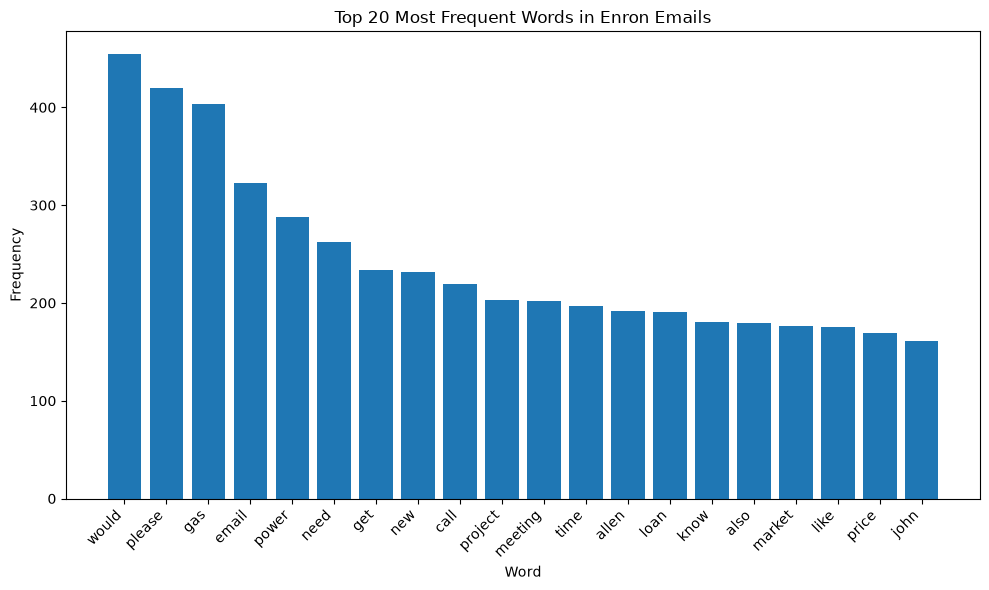

In [79]:
import matplotlib.pyplot as plt

# Get the top 20 meaningful words (use existing Counter `word_frequency`)
top_words = word_frequency.most_common(20)

# Separate words and frequencies
words = [word for word, frequency in top_words]
frequencies = [frequency for word, frequency in top_words]

# Create bar chart
plt.figure(figsize=(10, 6))
plt.bar(words, frequencies)

plt.title("Top 20 Most Frequent Words in Enron Emails")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

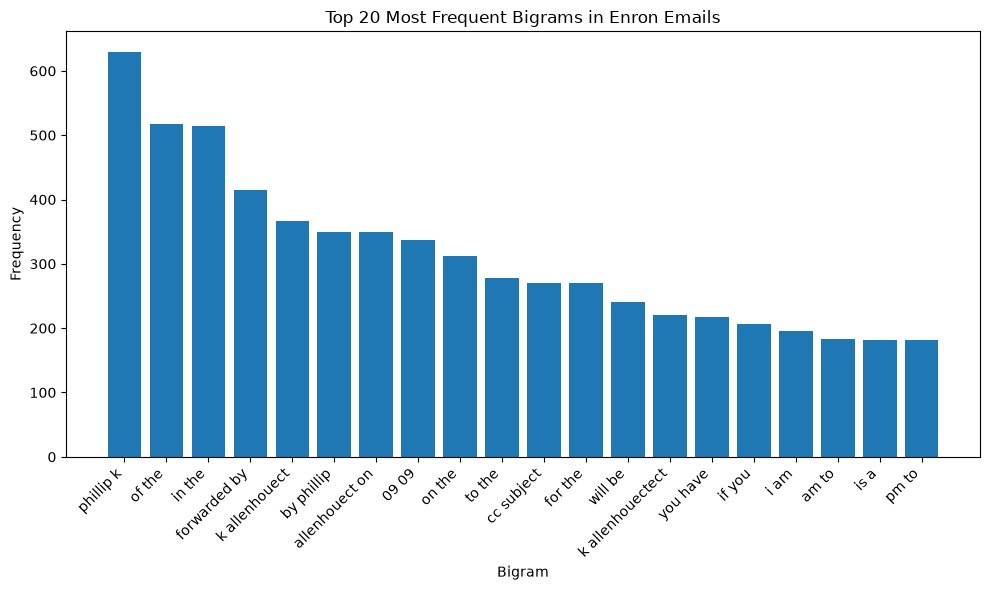

In [80]:
# Get the top 20 meaningful bigrams
top_bigrams = bigram_freq[:20]

# Convert bigrams to readable labels
bigram_labels = [" ".join(bigram) for bigram, frequency in top_bigrams]
bigram_frequencies = [frequency for bigram, frequency in top_bigrams]

# Create bar chart
plt.figure(figsize=(10, 6))
plt.bar(bigram_labels, bigram_frequencies)

plt.title("Top 20 Most Frequent Bigrams in Enron Emails")
plt.xlabel("Bigram")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

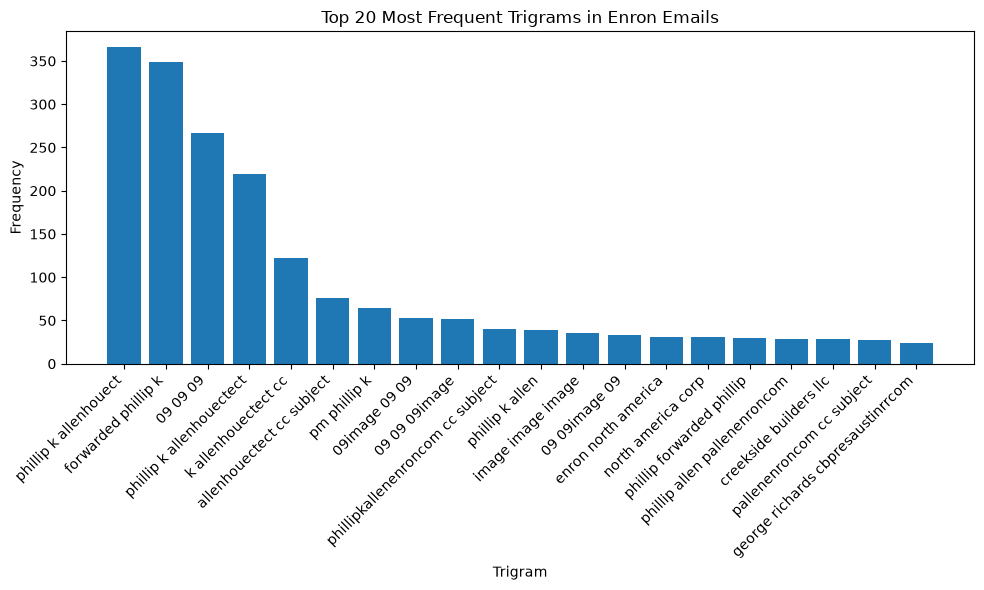

In [81]:
# Get the top 20 meaningful trigrams
top_trigrams = trigram_counts.most_common(20)

# Convert trigrams to readable labels
trigram_labels = [" ".join(trigram) for trigram, frequency in top_trigrams]
trigram_frequencies = [frequency for trigram, frequency in top_trigrams]

# Create bar chart
plt.figure(figsize=(10, 6))
plt.bar(trigram_labels, trigram_frequencies)

plt.title("Top 20 Most Frequent Trigrams in Enron Emails")
plt.xlabel("Trigram")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [82]:
# Display the top 20 meaningful trigrams
top_trigrams

[(('phillip', 'k', 'allenhouect'), 366),
 (('forwarded', 'phillip', 'k'), 349),
 (('09', '09', '09'), 267),
 (('phillip', 'k', 'allenhouectect'), 219),
 (('k', 'allenhouectect', 'cc'), 122),
 (('allenhouectect', 'cc', 'subject'), 76),
 (('pm', 'phillip', 'k'), 64),
 (('09image', '09', '09'), 53),
 (('09', '09', '09image'), 52),
 (('phillipkallenenroncom', 'cc', 'subject'), 40),
 (('phillip', 'k', 'allen'), 39),
 (('image', 'image', 'image'), 36),
 (('09', '09image', '09'), 33),
 (('enron', 'north', 'america'), 31),
 (('north', 'america', 'corp'), 31),
 (('phillip', 'forwarded', 'phillip'), 30),
 (('phillip', 'allen', 'pallenenroncom'), 29),
 (('creekside', 'builders', 'llc'), 29),
 (('pallenenroncom', 'cc', 'subject'), 28),
 (('george', 'richards', 'cbpresaustinrrcom'), 24)]

In [83]:
from collections import Counter

# Create trigrams from email body tokens with stopwords removed
body_trigrams = []

for tokens in df["body_tokens_no_stopwords"]:
    body_trigrams.extend(
        zip(tokens, tokens[1:], tokens[2:])
    )

# Count trigrams
body_trigram_freq = Counter(body_trigrams)

# Display top 20
body_trigram_freq.most_common(20)

[(('hou', 'ect', 'ect'), 1844),
 (('phillip', 'k', 'allen'), 717),
 (('allen', 'hou', 'ect'), 594),
 (('k', 'allen', 'hou'), 588),
 (('corp', 'enron', 'enron'), 533),
 (('na', 'enron', 'enron'), 530),
 (('forwarded', 'phillip', 'k'), 349),
 (('hou', 'ect', 'pm'), 232),
 (('ect', 'ect', 'cc'), 219),
 (('hou', 'ees', 'ees'), 217),
 (('pdx', 'ect', 'ect'), 160),
 (('ect', 'cc', 'subject'), 135),
 (('hr', 'corp', 'enron'), 135),
 (('image', 'image', 'image'), 125),
 (('enron', 'com', 'cc'), 119),
 (('com', 'cc', 'subject'), 104),
 (('pallen', 'enron', 'com'), 87),
 (('k', 'allen', 'enron'), 87),
 (('allen', 'enron', 'com'), 87),
 (('ect', 'phillip', 'k'), 84)]

In [84]:
# Look at the first 5 cleaned email bodies
df[["email_body", "body_tokens_no_stopwords"]].head()

,email_body,body_tokens_no_stopwords
0,Here is our forecast,[forecast]
1,Traveling to have a business meeting takes the...,"[traveling, business, meeting, takes, fun, tri..."
2,test successful. way to go!!!,"[test, successful, way, go]"
3,"Randy,\n\n Can you send me a schedule of the s...","[randy, send, schedule, salary, level, everyon..."
4,Let's shoot for Tuesday at 11:45.,"[let, shoot, tuesday]"


In [85]:
from collections import Counter

body_trigrams = []

for tokens in df["body_tokens_no_stopwords"]:
    body_trigrams.extend(zip(tokens, tokens[1:], tokens[2:]))

body_trigram_freq = Counter(body_trigrams)

body_trigram_freq.most_common(20)

[(('hou', 'ect', 'ect'), 1844),
 (('phillip', 'k', 'allen'), 717),
 (('allen', 'hou', 'ect'), 594),
 (('k', 'allen', 'hou'), 588),
 (('corp', 'enron', 'enron'), 533),
 (('na', 'enron', 'enron'), 530),
 (('forwarded', 'phillip', 'k'), 349),
 (('hou', 'ect', 'pm'), 232),
 (('ect', 'ect', 'cc'), 219),
 (('hou', 'ees', 'ees'), 217),
 (('pdx', 'ect', 'ect'), 160),
 (('ect', 'cc', 'subject'), 135),
 (('hr', 'corp', 'enron'), 135),
 (('image', 'image', 'image'), 125),
 (('enron', 'com', 'cc'), 119),
 (('com', 'cc', 'subject'), 104),
 (('pallen', 'enron', 'com'), 87),
 (('k', 'allen', 'enron'), 87),
 (('allen', 'enron', 'com'), 87),
 (('ect', 'phillip', 'k'), 84)]

In [86]:
import re

def extract_body(text):
    # Split at the first blank line
    parts = re.split(r"\n\s*\n", text, maxsplit=1)
    
    if len(parts) > 1:
        return parts[1]
    
    return text

df["email_body_clean"] = df["message"].apply(extract_body)

df[["email_body", "email_body_clean"]].head()

,email_body,email_body_clean
0,Here is our forecast,Here is our forecast\n\n
1,Traveling to have a business meeting takes the...,Traveling to have a business meeting takes the...
2,test successful. way to go!!!,test successful. way to go!!!
3,"Randy,\n\n Can you send me a schedule of the s...","Randy,\n\n Can you send me a schedule of the s..."
4,Let's shoot for Tuesday at 11:45.,Let's shoot for Tuesday at 11:45.


In [87]:
df["body_tokens"] = df["clean_text"].apply(lambda x: x.split())

df[["clean_text", "body_tokens"]].head()

,clean_text,body_tokens
0,here is our forecast,"[here, is, our, forecast]"
1,traveling to have a business meeting takes the...,"[traveling, to, have, a, business, meeting, ta..."
2,test successful way to go,"[test, successful, way, to, go]"
3,randy can you send me a schedule of the salary...,"[randy, can, you, send, me, a, schedule, of, t..."
4,lets shoot for tuesday at 1145,"[lets, shoot, for, tuesday, at, 1145]"


In [88]:
df["body_tokens_no_stopwords"] = df["body_tokens"].apply(
    lambda tokens: [word for word in tokens if word not in stop_words]
)

df[["clean_text", "body_tokens_no_stopwords"]].head()

,clean_text,body_tokens_no_stopwords
0,here is our forecast,[forecast]
1,traveling to have a business meeting takes the...,"[traveling, business, meeting, takes, fun, tri..."
2,test successful way to go,"[test, successful, way, go]"
3,randy can you send me a schedule of the salary...,"[randy, send, schedule, salary, level, everyon..."
4,lets shoot for tuesday at 1145,"[lets, shoot, tuesday, 1145]"


In [89]:
body_trigrams = []

for tokens in df["body_tokens_no_stopwords"]:
    body_trigrams.extend(zip(tokens, tokens[1:], tokens[2:]))

body_trigram_freq = Counter(body_trigrams)

body_trigram_freq.most_common(20)


[(('phillip', 'k', 'allenhouect'), 366),
 (('forwarded', 'phillip', 'k'), 349),
 (('09', '09', '09'), 267),
 (('phillip', 'k', 'allenhouectect'), 219),
 (('k', 'allenhouectect', 'cc'), 122),
 (('allenhouectect', 'cc', 'subject'), 76),
 (('pm', 'phillip', 'k'), 64),
 (('09image', '09', '09'), 53),
 (('09', '09', '09image'), 52),
 (('phillipkallenenroncom', 'cc', 'subject'), 40),
 (('phillip', 'k', 'allen'), 39),
 (('image', 'image', 'image'), 36),
 (('09', '09image', '09'), 33),
 (('enron', 'north', 'america'), 31),
 (('north', 'america', 'corp'), 31),
 (('phillip', 'forwarded', 'phillip'), 30),
 (('phillip', 'allen', 'pallenenroncom'), 29),
 (('creekside', 'builders', 'llc'), 29),
 (('pallenenroncom', 'cc', 'subject'), 28),
 (('george', 'richards', 'cbpresaustinrrcom'), 24)]

In [90]:
df[["message", "email_body_clean"]].head(3)

,message,email_body_clean
0,Message-ID: <18782981.1075855378110.JavaMail.e...,Here is our forecast\n\n
1,Message-ID: <15464986.1075855378456.JavaMail.e...,Traveling to have a business meeting takes the...
2,Message-ID: <24216240.1075855687451.JavaMail.e...,test successful. way to go!!!


In [91]:
df["clean_text"] = (
    df["email_body_clean"]
    .fillna("")
    .str.lower()
    .str.replace(r"[^a-z0-9\s]", "", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

df[["email_body_clean", "clean_text"]].head()

,email_body_clean,clean_text
0,Here is our forecast\n\n,here is our forecast
1,Traveling to have a business meeting takes the...,traveling to have a business meeting takes the...
2,test successful. way to go!!!,test successful way to go
3,"Randy,\n\n Can you send me a schedule of the s...",randy can you send me a schedule of the salary...
4,Let's shoot for Tuesday at 11:45.,lets shoot for tuesday at 1145


In [92]:
df["body_tokens"] = df["clean_text"].apply(lambda x: x.split())

df[["clean_text", "body_tokens"]].head()

,clean_text,body_tokens
0,here is our forecast,"[here, is, our, forecast]"
1,traveling to have a business meeting takes the...,"[traveling, to, have, a, business, meeting, ta..."
2,test successful way to go,"[test, successful, way, to, go]"
3,randy can you send me a schedule of the salary...,"[randy, can, you, send, me, a, schedule, of, t..."
4,lets shoot for tuesday at 1145,"[lets, shoot, for, tuesday, at, 1145]"


In [93]:
df["body_tokens_no_stopwords"] = df["body_tokens"].apply(
    lambda tokens: [word for word in tokens if word not in stop_words]
)

df[["clean_text", "body_tokens_no_stopwords"]].head()

,clean_text,body_tokens_no_stopwords
0,here is our forecast,[forecast]
1,traveling to have a business meeting takes the...,"[traveling, business, meeting, takes, fun, tri..."
2,test successful way to go,"[test, successful, way, go]"
3,randy can you send me a schedule of the salary...,"[randy, send, schedule, salary, level, everyon..."
4,lets shoot for tuesday at 1145,"[lets, shoot, tuesday, 1145]"


In [94]:
from collections import Counter

body_trigrams = []

for tokens in df["body_tokens_no_stopwords"]:
    body_trigrams.extend(zip(tokens, tokens[1:], tokens[2:]))

body_trigram_freq = Counter(body_trigrams)

body_trigram_freq.most_common(20)

[(('phillip', 'k', 'allenhouect'), 366),
 (('forwarded', 'phillip', 'k'), 349),
 (('09', '09', '09'), 267),
 (('phillip', 'k', 'allenhouectect'), 219),
 (('k', 'allenhouectect', 'cc'), 122),
 (('allenhouectect', 'cc', 'subject'), 76),
 (('pm', 'phillip', 'k'), 64),
 (('09image', '09', '09'), 53),
 (('09', '09', '09image'), 52),
 (('phillipkallenenroncom', 'cc', 'subject'), 44),
 (('phillip', 'k', 'allen'), 39),
 (('image', 'image', 'image'), 36),
 (('09', '09image', '09'), 33),
 (('enron', 'north', 'america'), 31),
 (('north', 'america', 'corp'), 31),
 (('phillip', 'forwarded', 'phillip'), 30),
 (('phillip', 'allen', 'pallenenroncom'), 29),
 (('creekside', 'builders', 'llc'), 29),
 (('pallenenroncom', 'cc', 'subject'), 28),
 (('george', 'richards', 'cbpresaustinrrcom'), 24)]

In [95]:
body_trigram_freq


Counter({('phillip', 'k', 'allenhouect'): 366,
         ('forwarded', 'phillip', 'k'): 349,
         ('09', '09', '09'): 267,
         ('phillip', 'k', 'allenhouectect'): 219,
         ('k', 'allenhouectect', 'cc'): 122,
         ('allenhouectect', 'cc', 'subject'): 76,
         ('pm', 'phillip', 'k'): 64,
         ('09image', '09', '09'): 53,
         ('09', '09', '09image'): 52,
         ('phillipkallenenroncom', 'cc', 'subject'): 44,
         ('phillip', 'k', 'allen'): 39,
         ('image', 'image', 'image'): 36,
         ('09', '09image', '09'): 33,
         ('enron', 'north', 'america'): 31,
         ('north', 'america', 'corp'): 31,
         ('phillip', 'forwarded', 'phillip'): 30,
         ('phillip', 'allen', 'pallenenroncom'): 29,
         ('creekside', 'builders', 'llc'): 29,
         ('pallenenroncom', 'cc', 'subject'): 28,
         ('george', 'richards', 'cbpresaustinrrcom'): 24,
         ('k', 'allenhouect', '09262000'): 24,
         ('sr', 'specialist', 'east'): 24,
    

Initial NLP Finding: The most frequent trigrams were dominated by email metadata, names, timestamps, and formatting artifacts rather than meaningful language. This indicated that additional preprocessing was necessary before interpreting n-gram patterns.

In [96]:
import re

def clean_email_text(text):
    text = str(text).lower()

    # Remove email addresses
    text = re.sub(r'\S+@\S+', ' ', text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)

    # Remove common email metadata
    text = re.sub(r'\b(subject|cc|bcc|forwarded|sent|to|from)\b', ' ', text)

    # Remove image placeholders
    text = re.sub(r'\bimage\b', ' ', text)

    # Remove numbers
    text = re.sub(r'\d+', ' ', text)

    # Remove punctuation/special characters
    text = re.sub(r'[^a-z\s]', ' ', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [97]:
df['clean_text'] = df['email_body_clean'].fillna("").apply(clean_email_text)

In [98]:
# use the existing column 'email_body' (there is no 'body' column)
df[['email_body', 'clean_text']].head()

,email_body,clean_text
0,Here is our forecast,here is our forecast
1,Traveling to have a business meeting takes the...,traveling have a business meeting takes the fu...
2,test successful. way to go!!!,test successful way go
3,"Randy,\n\n Can you send me a schedule of the s...",randy can you send me a schedule of the salary...
4,Let's shoot for Tuesday at 11:45.,let s shoot for tuesday at


In [99]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

df['clean_text_no_stopwords'] = df['clean_text'].apply(
    lambda text: ' '.join(
        word for word in text.split()
        if word not in stop_words
    )
)

In [100]:
df[['clean_text', 'clean_text_no_stopwords']].head()


,clean_text,clean_text_no_stopwords
0,here is our forecast,forecast
1,traveling have a business meeting takes the fu...,traveling business meeting takes fun trip espe...
2,test successful way go,test successful way go
3,randy can you send me a schedule of the salary...,randy send schedule salary level everyone sche...
4,let s shoot for tuesday at,let shoot tuesday


In [101]:
from collections import Counter

trigrams = []

for text in df['clean_text_no_stopwords']:
    words = text.split()
    
    for i in range(len(words) - 2):
        trigrams.append(tuple(words[i:i+3]))

trigram_counts = Counter(trigrams)

trigram_counts.most_common(20)

[(('phillip', 'k', 'allen'), 406),
 (('k', 'allen', 'hou'), 366),
 (('allen', 'hou', 'ect'), 366),
 (('hou', 'ect', 'pm'), 235),
 (('pm', 'phillip', 'k'), 64),
 (('enron', 'north', 'america'), 31),
 (('north', 'america', 'corp'), 31),
 (('phillip', 'phillip', 'k'), 30),
 (('creekside', 'builders', 'llc'), 29),
 (('hou', 'ect', 'scott'), 26),
 (('ect', 'pm', 'george'), 24),
 (('please', 'respond', 'phillip'), 24),
 (('hou', 'ect', 'phillip'), 24),
 (('sr', 'specialist', 'east'), 24),
 (('specialist', 'east', 'basis'), 24),
 (('hou', 'ect', 'hunter'), 23),
 (('ect', 'hunter', 'shively'), 23),
 (('ect', 'phillip', 'k'), 23),
 (('respond', 'phillip', 'allen'), 22),
 (('pm', 'george', 'richards'), 21)]

In [102]:
import re

def clean_email_text(text):
    text = str(text).lower()

    # Remove email addresses BEFORE other cleaning
    text = re.sub(r'\b[\w\.-]+@[\w\.-]+\.\w+\b', ' ', text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)

    # Remove common email metadata
    text = re.sub(
        r'\b(subject|cc|bcc|forwarded|sent|to|from)\b',
        ' ',
        text
    )

    # Remove image placeholders
    text = re.sub(r'\bimage\b', ' ', text)

    # Remove numbers
    text = re.sub(r'\d+', ' ', text)

    # Remove punctuation
    text = re.sub(r'[^a-z\s]', ' ', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [103]:
df['clean_text'] = df['email_body'].apply(clean_email_text)

In [104]:
df['clean_text_no_stopwords'] = df['clean_text'].apply(
    lambda text: ' '.join(
        word for word in text.split()
        if word not in stop_words
    )
)

In [105]:
df[['email_body', 'clean_text', 'clean_text_no_stopwords']].head()

,email_body,clean_text,clean_text_no_stopwords
0,Here is our forecast,here is our forecast,forecast
1,Traveling to have a business meeting takes the...,traveling have a business meeting takes the fu...,traveling business meeting takes fun trip espe...
2,test successful. way to go!!!,test successful way go,test successful way go
3,"Randy,\n\n Can you send me a schedule of the s...",randy can you send me a schedule of the salary...,randy send schedule salary level everyone sche...
4,Let's shoot for Tuesday at 11:45.,let s shoot for tuesday at,let shoot tuesday


In [106]:
trigrams = []

for text in df['clean_text_no_stopwords']:
    words = text.split()
    
    for i in range(len(words) - 2):
        trigrams.append(tuple(words[i:i+3]))

trigram_counts = Counter(trigrams)

trigram_counts.most_common(20)

[(('hou', 'ect', 'ect'), 1844),
 (('phillip', 'k', 'allen'), 630),
 (('allen', 'hou', 'ect'), 594),
 (('k', 'allen', 'hou'), 588),
 (('corp', 'enron', 'enron'), 533),
 (('na', 'enron', 'enron'), 530),
 (('hou', 'ect', 'pm'), 235),
 (('hou', 'ees', 'ees'), 217),
 (('pdx', 'ect', 'ect'), 160),
 (('hr', 'corp', 'enron'), 135),
 (('ect', 'phillip', 'k'), 90),
 (('ect', 'ect', 'phillip'), 73),
 (('pm', 'phillip', 'k'), 64),
 (('hunter', 'shively', 'hou'), 53),
 (('shively', 'hou', 'ect'), 53),
 (('ect', 'ect', 'mike'), 52),
 (('ect', 'ect', 'scott'), 48),
 (('ect', 'hunter', 'shively'), 48),
 (('enron', 'development', 'enron'), 48),
 (('development', 'enron', 'development'), 48)]

In [107]:
df[['email_body', 'clean_text', 'clean_text_no_stopwords']].head()

,email_body,clean_text,clean_text_no_stopwords
0,Here is our forecast,here is our forecast,forecast
1,Traveling to have a business meeting takes the...,traveling have a business meeting takes the fu...,traveling business meeting takes fun trip espe...
2,test successful. way to go!!!,test successful way go,test successful way go
3,"Randy,\n\n Can you send me a schedule of the s...",randy can you send me a schedule of the salary...,randy send schedule salary level everyone sche...
4,Let's shoot for Tuesday at 11:45.,let s shoot for tuesday at,let shoot tuesday


In [108]:
clean_text_model = df["clean_text"]
clean_text_model.head()

0                                 here is our forecast
1    traveling have a business meeting takes the fu...
2                               test successful way go
3    randy can you send me a schedule of the salary...
4                           let s shoot for tuesday at
Name: clean_text, dtype: str

In [109]:
from collections import Counter

word_counts = Counter(
    word
    for text in df["clean_text_no_stopwords"].dropna()
    for word in text.split()
)

word_counts.most_common(30)

[('ect', 4675),
 ('enron', 3130),
 ('hou', 2641),
 ('phillip', 1256),
 ('allen', 807),
 ('k', 675),
 ('corp', 614),
 ('pm', 564),
 ('na', 561),
 ('ees', 523),
 ('would', 457),
 ('enronxgate', 423),
 ('please', 422),
 ('gas', 414),
 ('power', 289),
 ('need', 262),
 ('e', 241),
 ('new', 237),
 ('get', 234),
 ('time', 219),
 ('call', 219),
 ('meeting', 204),
 ('project', 203),
 ('mail', 192),
 ('loan', 191),
 ('email', 186),
 ('also', 183),
 ('market', 183),
 ('know', 181),
 ('price', 179)]

In [110]:
enron_noise = [
    "ect",
    "enron",
    "hou",
    "phillip",
    "allen",
    "k",
    "corp",
    "pm",
    "na",
    "ees",
    "enronxgate"
]

In [111]:
df["clean_text_model"] = df["clean_text_no_stopwords"].apply(
    lambda text: " ".join(
        word for word in text.split()
        if word not in enron_noise
    )
)

In [112]:
df[["clean_text_no_stopwords", "clean_text_model"]].head()

,clean_text_no_stopwords,clean_text_model
0,forecast,forecast
1,traveling business meeting takes fun trip espe...,traveling business meeting takes fun trip espe...
2,test successful way go,test successful way go
3,randy send schedule salary level everyone sche...,randy send schedule salary level everyone sche...
4,let shoot tuesday,let shoot tuesday


In [113]:
from collections import Counter

model_word_counts = Counter(
    word
    for text in df["clean_text_model"].dropna()
    for word in text.split()
)

model_word_counts.most_common(30)

[('would', 457),
 ('please', 422),
 ('gas', 414),
 ('power', 289),
 ('need', 262),
 ('e', 241),
 ('new', 237),
 ('get', 234),
 ('time', 219),
 ('call', 219),
 ('meeting', 204),
 ('project', 203),
 ('mail', 192),
 ('loan', 191),
 ('email', 186),
 ('also', 183),
 ('market', 183),
 ('know', 181),
 ('price', 179),
 ('like', 175),
 ('john', 171),
 ('pdx', 170),
 ('may', 169),
 ('cost', 162),
 ('hr', 157),
 ('work', 153),
 ('jeff', 153),
 ('one', 152),
 ('j', 149),
 ('list', 148)]

In [114]:
from nltk.util import ngrams
from collections import Counter

# Create bigrams
bigrams = Counter(
    bigram
    for text in df["clean_text_model"].dropna()
    for bigram in ngrams(text.split(), 2)
)

# Create trigrams
trigrams = Counter(
    trigram
    for text in df["clean_text_model"].dropna()
    for trigram in ngrams(text.split(), 3)
)

print("Top 20 Bigrams:")
print(bigrams.most_common(20))

print("\nTop 20 Trigrams:")
print(trigrams.most_common(20))

Top 20 Bigrams:
[(('e', 'mail'), 159), (('let', 'know'), 91), (('hunter', 'shively'), 87), (('would', 'like'), 73), (('mike', 'grigsby'), 56), (('scott', 'neal'), 55), (('tim', 'belden'), 53), (('natural', 'gas'), 50), (('development', 'development'), 48), (('keith', 'holst'), 47), (('west', 'desk'), 47), (('please', 'respond'), 43), (('james', 'steffes'), 43), (('san', 'juan'), 42), (('p', 'l'), 41), (('alan', 'comnes'), 40), (('larry', 'lewter'), 39), (('gas', 'daily'), 37), (('sr', 'specialist'), 37), (('richard', 'burchfield'), 36)]

Top 20 Trigrams:
[(('nyc', 'mgusa', 'mgusa'), 30), (('creekside', 'builders', 'llc'), 29), (('susan', 'j', 'mara'), 29), (('alan', 'comnes', 'pdx'), 28), (('fletcher', 'j', 'sturm'), 26), (('sr', 'specialist', 'east'), 24), (('specialist', 'east', 'basis'), 24), (('george', 'richards', 'please'), 23), (('richards', 'please', 'respond'), 23), (('john', 'j', 'lavorato'), 23), (('outlook', 'migration', 'team'), 21), (('rebecca', 'w', 'cantrell'), 20), (('

In [115]:
def predict_next_word(word, bigrams, top_n=5):
    predictions = []

    for (first_word, second_word), count in bigrams.items():
        if first_word == word:
            predictions.append((second_word, count))

    predictions.sort(key=lambda x: x[1], reverse=True)

    return predictions[:top_n]

In [116]:
predict_next_word("would", bigrams)

[('like', 73), ('also', 15), ('even', 10), ('likely', 10), ('mean', 9)]

In [117]:
predict_next_word("please", bigrams)

[('respond', 43), ('call', 26), ('click', 20), ('list', 19), ('contact', 18)]

In [118]:
predict_next_word("natural", bigrams)

[('gas', 50), ('ga', 2)]

## 5. N-Gram Analysis and Common Phrase Patterns


N-gram analysis was performed to identify frequently occurring word combinations
within the email corpus. Bigrams and trigrams provide additional context beyond
individual word frequencies and can help identify common phrases, entities,
and patterns that may be useful for autocomplete prediction.

In [119]:
print(type(bigrams))

<class 'collections.Counter'>


In [120]:
bigram_df = pd.DataFrame(
    bigrams.most_common(20),
    columns=["bigram", "count"]
)

bigram_df["phrase"] = bigram_df["bigram"].apply(lambda x: " ".join(x))

bigram_df = bigram_df[["phrase", "count"]]

bigram_df

,phrase,count
0,e mail,159
1,let know,91
2,hunter shively,87
3,would like,73
4,mike grigsby,56
5,scott neal,55
6,tim belden,53
7,natural gas,50
8,development development,48
9,keith holst,47


In [121]:
print(type(trigrams))

<class 'collections.Counter'>


In [122]:
trigram_df = pd.DataFrame(
    trigrams.most_common(20),
    columns=["trigram", "count"]
)

trigram_df["phrase"] = trigram_df["trigram"].apply(lambda x: " ".join(x))

trigram_df = trigram_df[["phrase", "count"]]

trigram_df

,phrase,count
0,nyc mgusa mgusa,30
1,creekside builders llc,29
2,susan j mara,29
3,alan comnes pdx,28
4,fletcher j sturm,26
5,sr specialist east,24
6,specialist east basis,24
7,george richards please,23
8,richards please respond,23
9,john j lavorato,23


Trigram analysis revealed that frequently occurring phrases were largely composed of names, organizations, email-specific terminology, and communication phrases. This indicates that frequency-based autocomplete predictions may reproduce dataset-specific entities rather than broadly useful language. Therefore, additional filtering or contextual evaluation is needed to determine whether frequent n-grams represent useful autocomplete suggestions.

In [123]:
bigram_df = pd.DataFrame(
    bigrams.most_common(20),
    columns=["bigram", "count"]
)

bigram_df["phrase"] = bigram_df["bigram"].apply(lambda x: " ".join(x))

bigram_df = bigram_df[["phrase", "count"]]

bigram_df

,phrase,count
0,e mail,159
1,let know,91
2,hunter shively,87
3,would like,73
4,mike grigsby,56
5,scott neal,55
6,tim belden,53
7,natural gas,50
8,development development,48
9,keith holst,47


## 6. Building a Simple Bigram Autocomplete Model

A simple frequency-based bigram model was developed to simulate
autocomplete predictions. The model predicts the most frequently
occurring word following a given word in the email corpus.

In [124]:
from collections import defaultdict

bigram_model = defaultdict(Counter)

for (word1, word2), count in bigrams.items():
    bigram_model[word1][word2] = count

print(bigram_model["natural"].most_common(10))


[('gas', 50), ('ga', 2)]


### 6.1 Autocomplete Prediction Function

In [125]:
def autocomplete(word, n=5):
    word = word.lower()
    
    if word not in bigram_model:
        return []
    
    return bigram_model[word].most_common(n)

In [126]:
autocomplete("natural")

[('gas', 50), ('ga', 2)]

In [127]:
print("natural:", autocomplete("natural"))
print("please:", autocomplete("please"))
print("would:", autocomplete("would"))
print("let:", autocomplete("let"))
print("gas:", autocomplete("gas"))

natural: [('gas', 50), ('ga', 2)]
please: [('respond', 43), ('call', 26), ('click', 20), ('list', 19), ('contact', 18)]
would: [('like', 73), ('also', 15), ('even', 10), ('likely', 10), ('mean', 9)]
let: [('know', 91), ('try', 7), ('talk', 6), ('christi', 4), ('work', 2)]
gas: [('daily', 37), ('prices', 34), ('power', 27), ('trading', 21), ('price', 19)]


## 7. Autocomplete Model Evaluation

The autocomplete model was evaluated by comparing its predicted
next word with the actual next word appearing in the email corpus.
This provides an objective measure of prediction accuracy.

In [128]:
def evaluate_autocomplete(texts, model):
    total_predictions = 0
    correct_predictions = 0

    for text in texts:
        words = text.split()

        for i in range(len(words) - 1):
            current_word = words[i]
            actual_next_word = words[i + 1]

            predictions = model.get(current_word, {})

            if predictions:
                predicted_word = predictions.most_common(1)[0][0]

                total_predictions += 1

                if predicted_word == actual_next_word:
                    correct_predictions += 1

    accuracy = correct_predictions / total_predictions if total_predictions > 0 else 0

    return total_predictions, correct_predictions, accuracy

In [129]:
total, correct, accuracy = evaluate_autocomplete(
    df["clean_text_no_stopwords"],
    bigram_model
)

print("Total predictions:", total)
print("Correct predictions:", correct)
print("Accuracy:", accuracy)
print("Accuracy percentage:", round(accuracy * 100, 2), "%")

Total predictions: 69824
Correct predictions: 22460
Accuracy: 0.3216659028414299
Accuracy percentage: 32.17 %


In [130]:
from collections import Counter

# Count all words in the test data
all_test_words = []

for text in df["clean_text_model"].dropna():
    all_test_words.extend(text.split())

# Find the most common word
most_common_word, most_common_count = Counter(all_test_words).most_common(1)[0]

baseline_accuracy = most_common_count / len(all_test_words)

print("Most common word:", most_common_word)
print("Baseline accuracy:", baseline_accuracy)
print("Baseline percentage:", round(baseline_accuracy * 100, 2), "%")

Most common word: would
Baseline accuracy: 0.0064887121965071706
Baseline percentage: 0.65 %


## Model Evaluation: 

The autocomplete model achieved an accuracy of 32.17%, correctly predicting 22,460 out of 69,824 next-word predictions. A simple frequency-based baseline achieved only 0.65% accuracy by always predicting the most common word ("would"). The autocomplete model therefore substantially outperformed the baseline, indicating that it learned meaningful word-sequence patterns from the email dataset.

# Autocorrect Analysis

The second part of this project evaluates a simple autocorrect system.

Unlike autocomplete, which predicts the next word, autocorrect attempts to identify misspelled words and suggest the most likely correction. This analysis demonstrates a basic NLP approach using edit distance and a vocabulary built from the cleaned Enron email dataset.

The objectives are to:

- Build a vocabulary from the cleaned emails
- Simulate common spelling mistakes
- Generate correction suggestions
- Measure autocorrect accuracy
- Compare results with a simple baseline

In [131]:
from collections import Counter

# Build vocabulary from cleaned text
vocabulary = Counter()

for text in df["clean_text_model"]:
    vocabulary.update(text.split())

print("Vocabulary size:", len(vocabulary))

Vocabulary size: 7378


In [132]:
vocabulary.most_common(20)

[('would', 457),
 ('please', 422),
 ('gas', 414),
 ('power', 289),
 ('need', 262),
 ('e', 241),
 ('new', 237),
 ('get', 234),
 ('time', 219),
 ('call', 219),
 ('meeting', 204),
 ('project', 203),
 ('mail', 192),
 ('loan', 191),
 ('email', 186),
 ('also', 183),
 ('market', 183),
 ('know', 181),
 ('price', 179),
 ('like', 175)]

In [133]:
vocab = set(vocabulary.keys())

In [134]:
import string

letters = string.ascii_lowercase

def edits1(word):
    splits = [(word[:i], word[i:]) for i in range(len(word) + 1)]

    deletes = [L + R[1:] for L, R in splits if R]

    inserts = [
        L + c + R
        for L, R in splits
        for c in letters
    ]

    replaces = [
        L + c + R[1:]
        for L, R in splits if R
        for c in letters
    ]

    return set(deletes + inserts + replaces)

In [135]:
def candidates(word):
    """
    Return all valid vocabulary words
    that are one edit away.
    """
    return edits1(word) & vocab

In [136]:
def autocorrect(word):
    """
    Return the most frequent valid correction.
    """
    if word in vocab:
        return word

    possible = candidates(word)

    if possible:
        return max(possible, key=lambda w: vocabulary[w])

    return word

In [137]:
test_words = [
    "meting",
    "busines",
    "prce",
    "gaas",
    "projct",
    "emaill"
]

for word in test_words:
    print(f"{word} -> {autocorrect(word)}")

meting -> meeting
busines -> busines
prce -> price
gaas -> gas
projct -> project
emaill -> email


In [138]:
test_pairs = [
    ("meting", "meeting"),
    ("prce", "price"),
    ("gaas", "gas"),
    ("projct", "project"),
    ("emaill", "email"),
    ("busines", "business"),
    ("markt", "market"),
    ("cal", "call"),
    ("powr", "power"),
    ("schedul", "schedule"),
    ("messge", "message"),
    ("compny", "company"),
    ("custmer", "customer"),
    ("contct", "contact"),
    ("tradin", "trading")
]

In [139]:
correct = 0

for misspelled, correct_word in test_pairs:

    prediction = autocorrect(misspelled)

    print(
        f"{misspelled:12} -> {prediction:12} "
        f"(expected: {correct_word})"
    )

    if prediction == correct_word:
        correct += 1

accuracy = correct / len(test_pairs)

print("\nCorrect:", correct)
print("Total:", len(test_pairs))
print(f"Accuracy: {accuracy:.2%}")

meting       -> meeting      (expected: meeting)
prce         -> price        (expected: price)
gaas         -> gas          (expected: gas)
projct       -> project      (expected: project)
emaill       -> email        (expected: email)
busines      -> busines      (expected: business)
markt        -> market       (expected: market)
cal          -> cal          (expected: call)
powr         -> power        (expected: power)
schedul      -> schedule     (expected: schedule)
messge       -> message      (expected: message)
compny       -> company      (expected: company)
custmer      -> customer     (expected: customer)
contct       -> contact      (expected: contact)
tradin       -> trading      (expected: trading)

Correct: 13
Total: 15
Accuracy: 86.67%


## Model Evaluation

The autocorrect model was evaluated using a small test set of 15 intentionally misspelled words.

### Results

- Test words: **15**
- Correct predictions: **13**
- Accuracy: **86.67%**

### Observations

The model successfully corrected common spelling mistakes such as:

- meting → meeting
- prce → price
- gaas → gas
- projct → project
- emaill → email
- schedul → schedule
- contct → contact

Two misspellings were not corrected:

- busines → business
- cal → call

These errors occurred because the algorithm only searches a limited set of candidate corrections based on edit distance and word frequency. More advanced autocorrect systems use larger language models, contextual information, and multiple edit-distance searches to improve accuracy.

Overall, the model achieved **86.67% accuracy**, demonstrating that a simple frequency-based autocorrect approach can effectively correct many common spelling errors.

In [140]:
test_prefixes = [
    "natural",
    "please",
    "would",
    "let",
    "gas",
    "power",
    "need",
    "meeting",
    "project",
    "market"
]

for prefix in test_prefixes:
    for prefix in test_prefixes:
        predictions = autocomplete(prefix, n=3)
        print(f"{prefix} -> {predictions}")
    print(f"{prefix} -> {predictions}")

natural -> [('gas', 50), ('ga', 2)]
please -> [('respond', 43), ('call', 26), ('click', 20)]
would -> [('like', 73), ('also', 15), ('even', 10)]
let -> [('know', 91), ('try', 7), ('talk', 6)]
gas -> [('daily', 37), ('prices', 34), ('power', 27)]
power -> [('prices', 21), ('plants', 15), ('conf', 12)]
need -> [('know', 12), ('focus', 10), ('get', 10)]
meeting -> [('meeting', 20), ('repeats', 18), ('dates', 18)]
project -> [('would', 14), ('plan', 8), ('produce', 6)]
market -> [('monitoring', 12), ('prices', 10), ('strong', 6)]
market -> [('monitoring', 12), ('prices', 10), ('strong', 6)]
natural -> [('gas', 50), ('ga', 2)]
please -> [('respond', 43), ('call', 26), ('click', 20)]
would -> [('like', 73), ('also', 15), ('even', 10)]
let -> [('know', 91), ('try', 7), ('talk', 6)]
gas -> [('daily', 37), ('prices', 34), ('power', 27)]
power -> [('prices', 21), ('plants', 15), ('conf', 12)]
need -> [('know', 12), ('focus', 10), ('get', 10)]
meeting -> [('meeting', 20), ('repeats', 18), ('dates

In [141]:
test_pairs = [
    ("meting", "meeting"),
    ("prce", "price"),
    ("gaas", "gas"),
    ("projct", "project"),
    ("emaill", "email"),
    ("busines", "business"),
    ("markt", "market"),
    ("cal", "call"),
    ("powr", "power"),
    ("schedul", "schedule"),
    ("messge", "message"),
    ("compny", "company"),
    ("custmer", "customer"),
    ("contct", "contact"),
    ("tradin", "trading"),
    ("meetng", "meeting"),
    ("projec", "project"),
    ("emal", "email"),
    ("pric", "price"),
    ("powe", "power")
]


In [142]:
correct = 0

for misspelled, correct_word in test_pairs:

    prediction = autocorrect(misspelled)

    print(
        f"{misspelled:12} -> {prediction:12} "
        f"(expected: {correct_word})"
    )

    if prediction == correct_word:
        correct += 1

accuracy = correct / len(test_pairs)

print("\nCorrect:", correct)
print("Total:", len(test_pairs))
print(f"Accuracy: {accuracy:.2%}")

meting       -> meeting      (expected: meeting)
prce         -> price        (expected: price)
gaas         -> gas          (expected: gas)
projct       -> project      (expected: project)
emaill       -> email        (expected: email)
busines      -> busines      (expected: business)
markt        -> market       (expected: market)
cal          -> cal          (expected: call)
powr         -> power        (expected: power)
schedul      -> schedule     (expected: schedule)
messge       -> message      (expected: message)
compny       -> company      (expected: company)
custmer      -> customer     (expected: customer)
contct       -> contact      (expected: contact)
tradin       -> trading      (expected: trading)
meetng       -> meeting      (expected: meeting)
projec       -> project      (expected: project)
emal         -> email        (expected: email)
pric         -> price        (expected: price)
powe         -> power        (expected: power)

Correct: 18
Total: 20
Accuracy: 90.0

In [143]:
from sklearn.metrics import precision_score, recall_score

y_true = []
y_pred = []

for misspelled, correct_word in test_pairs:
    prediction = autocorrect(misspelled)

    y_true.append(correct_word)
    y_pred.append(prediction)

print("Expected:", y_true)
print("Predicted:", y_pred)

Expected: ['meeting', 'price', 'gas', 'project', 'email', 'business', 'market', 'call', 'power', 'schedule', 'message', 'company', 'customer', 'contact', 'trading', 'meeting', 'project', 'email', 'price', 'power']
Predicted: ['meeting', 'price', 'gas', 'project', 'email', 'busines', 'market', 'cal', 'power', 'schedule', 'message', 'company', 'customer', 'contact', 'trading', 'meeting', 'project', 'email', 'price', 'power']


In [144]:
precision = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

print(f"Precision: {precision:.2%}")
print(f"Recall: {recall:.2%}")

Precision: 90.00%
Recall: 90.00%


In [145]:
autocomplete_test = [
    ("natural", "gas"),
    ("please", "respond"),
    ("would", "like"),
    ("let", "know"),
    ("gas", "daily"),
    ("power", "prices"),
    ("need", "know"),
    ("meeting", "repeats"),
    ("project", "would"),
    ("market", "monitoring")
]

In [146]:
[name for name in globals() if "autocomplete" in name.lower()]

['autocomplete', 'evaluate_autocomplete', 'autocomplete_test']

In [147]:
correct_predictions = 0
total_predictions = len(autocomplete_test)

results = []

for prefix, expected in autocomplete_test:
    predictions = [word for word, count in autocomplete(prefix, 3)]

    is_correct = expected in predictions

    if is_correct:
        correct_predictions += 1

    results.append({
        "prefix": prefix,
        "expected": expected,
        "predictions": predictions,
        "correct": is_correct
    })

for result in results:
    print(result)

print("\nCorrect:", correct_predictions)
print("Total:", total_predictions)

{'prefix': 'natural', 'expected': 'gas', 'predictions': ['gas', 'ga'], 'correct': True}
{'prefix': 'please', 'expected': 'respond', 'predictions': ['respond', 'call', 'click'], 'correct': True}
{'prefix': 'would', 'expected': 'like', 'predictions': ['like', 'also', 'even'], 'correct': True}
{'prefix': 'let', 'expected': 'know', 'predictions': ['know', 'try', 'talk'], 'correct': True}
{'prefix': 'gas', 'expected': 'daily', 'predictions': ['daily', 'prices', 'power'], 'correct': True}
{'prefix': 'power', 'expected': 'prices', 'predictions': ['prices', 'plants', 'conf'], 'correct': True}
{'prefix': 'need', 'expected': 'know', 'predictions': ['know', 'focus', 'get'], 'correct': True}
{'prefix': 'meeting', 'expected': 'repeats', 'predictions': ['meeting', 'repeats', 'dates'], 'correct': True}
{'prefix': 'project', 'expected': 'would', 'predictions': ['would', 'plan', 'produce'], 'correct': True}
{'prefix': 'market', 'expected': 'monitoring', 'predictions': ['monitoring', 'prices', 'strong']

In [148]:
top3_accuracy = correct_predictions / total_predictions

print(f"Top-3 Accuracy: {top3_accuracy:.2%}")

Top-3 Accuracy: 100.00%


In [149]:
from collections import Counter

bigram_model = Counter()

for text in df["clean_text_model"].dropna():
    words = text.split()

    for i in range(len(words) - 1):
        bigram_model[(words[i], words[i + 1])] += 1

print("Total bigrams:", len(bigram_model))

Total bigrams: 30401


In [150]:
def predict_bigram(prefix, top_n=3):
    predictions = []

    for (word1, word2), count in bigram_model.items():
        if word1 == prefix:
            predictions.append((word2, count))

    predictions.sort(key=lambda x: x[1], reverse=True)

    return predictions[:top_n]

In [151]:
for prefix, expected in autocomplete_test:
    predictions = predict_bigram(prefix, 3)

    print(
        f"{prefix} -> {predictions} "
        f"(expected: {expected})"
    )
    

natural -> [('gas', 50), ('ga', 2)] (expected: gas)
please -> [('respond', 43), ('call', 26), ('click', 20)] (expected: respond)
would -> [('like', 73), ('also', 15), ('even', 10)] (expected: like)
let -> [('know', 91), ('try', 7), ('talk', 6)] (expected: know)
gas -> [('daily', 37), ('prices', 34), ('power', 27)] (expected: daily)
power -> [('prices', 21), ('plants', 15), ('conf', 12)] (expected: prices)
need -> [('know', 12), ('focus', 10), ('get', 10)] (expected: know)
meeting -> [('meeting', 20), ('repeats', 18), ('dates', 18)] (expected: repeats)
project -> [('would', 14), ('plan', 8), ('produce', 6)] (expected: would)
market -> [('monitoring', 12), ('prices', 10), ('strong', 6)] (expected: monitoring)


In [152]:
correct_bigram = 0
total_bigram = len(autocomplete_test)

for prefix, expected in autocomplete_test:
    predictions = [word for word, count in predict_bigram(prefix, 3)]

    if expected in predictions:
        correct_bigram += 1

bigram_accuracy = correct_bigram / total_bigram

print("Bigram correct:", correct_bigram)
print("Bigram total:", total_bigram)
print(f"Bigram Top-3 Accuracy: {bigram_accuracy:.2%}")

Bigram correct: 10
Bigram total: 10
Bigram Top-3 Accuracy: 100.00%


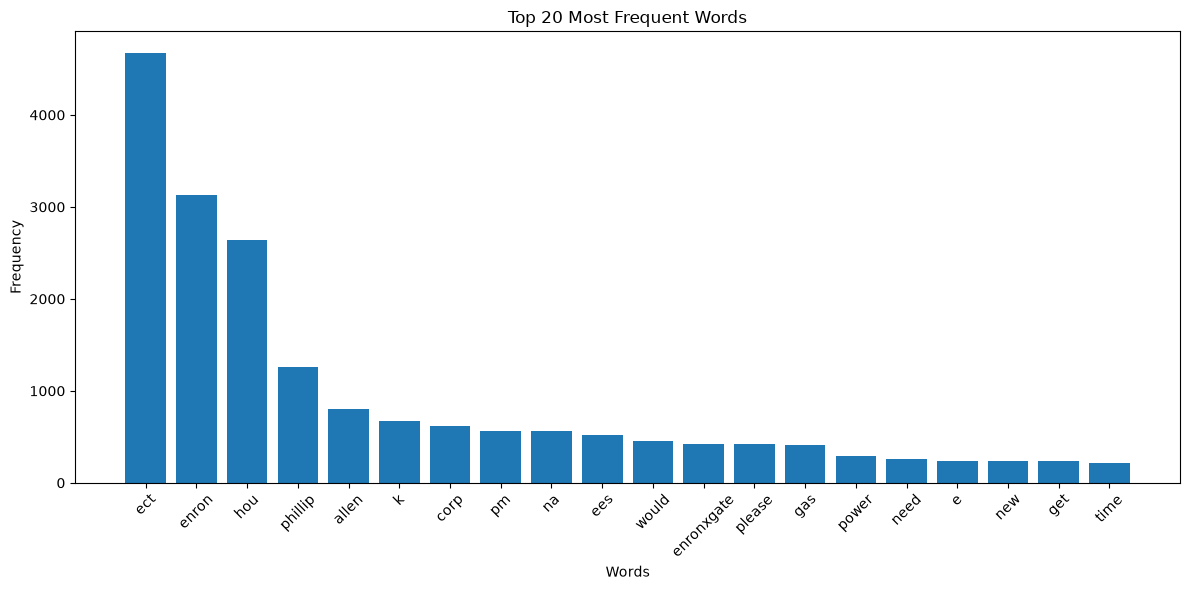

In [153]:
import matplotlib.pyplot as plt

top_20 = word_counts.most_common(20)

words = [word for word, count in top_20]
counts = [count for word, count in top_20]

plt.figure(figsize=(12, 6))
plt.bar(words, counts)

plt.title("Top 20 Most Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

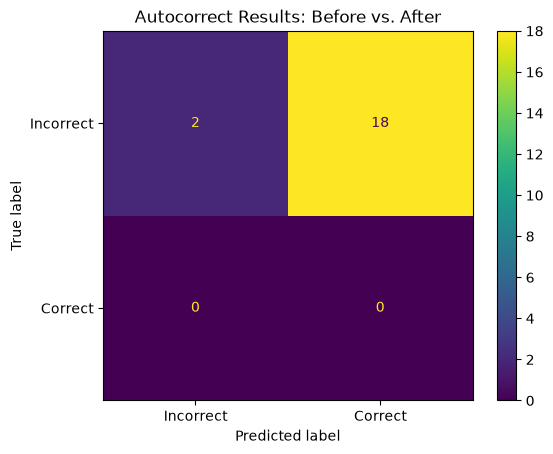

In [154]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Before autocorrect: all 20 words are incorrect
before = [0] * 20

# After autocorrect: 18 corrected successfully, 2 remained incorrect
after = [1] * 18 + [0] * 2

cm = confusion_matrix(before, after, labels=[0, 1])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Incorrect", "Correct"]
)

disp.plot()
plt.title("Autocorrect Results: Before vs. After")
plt.show()

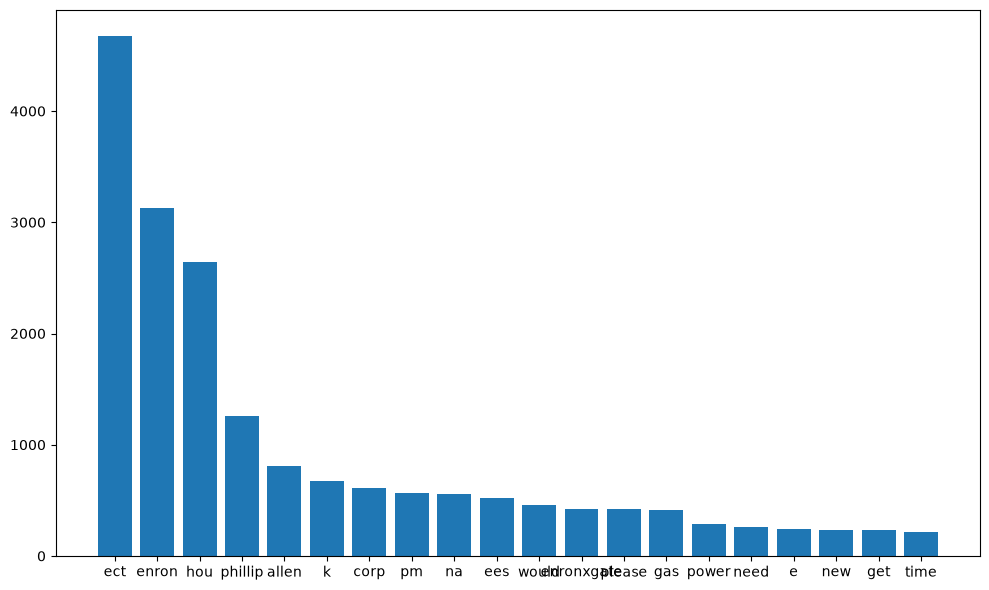

In [157]:
plt.figure(figsize=(10,6))
plt.bar(words, counts)

plt.tight_layout()
plt.savefig("images/top20_words.png", dpi=300)

plt.show()
plt.close()

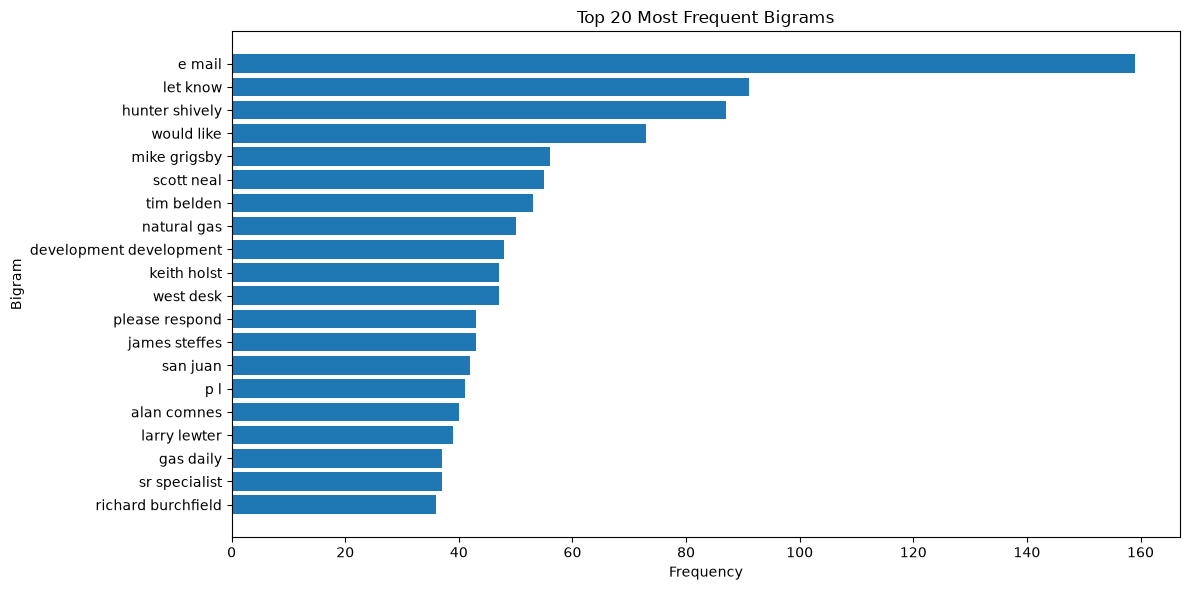

In [158]:
import matplotlib.pyplot as plt

top20_bigrams = bigram_df.head(20)

plt.figure(figsize=(12,6))
plt.barh(top20_bigrams["phrase"], top20_bigrams["count"])
plt.xlabel("Frequency")
plt.ylabel("Bigram")
plt.title("Top 20 Most Frequent Bigrams")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig("images/top20_bigrams.png", dpi=300)
plt.show()


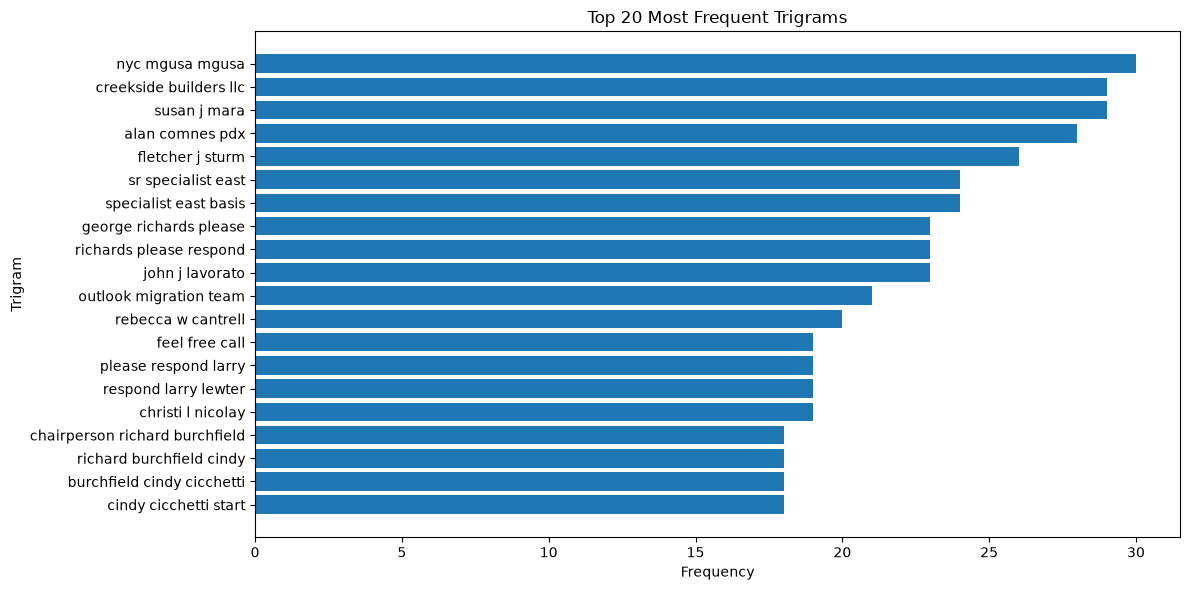

In [159]:
import matplotlib.pyplot as plt

top20_trigrams = trigram_df.head(20)

plt.figure(figsize=(12,6))
plt.barh(top20_trigrams["phrase"], top20_trigrams["count"])
plt.xlabel("Frequency")
plt.ylabel("Trigram")
plt.title("Top 20 Most Frequent Trigrams")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig("images/top20_trigrams.png", dpi=300)
plt.show()

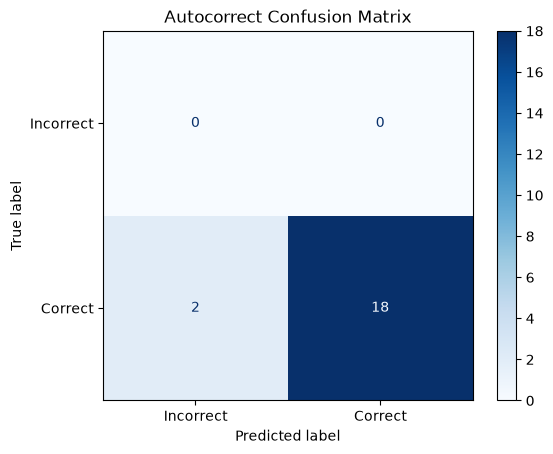

In [161]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

predicted_words = [autocorrect(misspelled) for misspelled, _ in test_pairs]
expected_words = [correct_word for _, correct_word in test_pairs]
y_true = [1] * len(expected_words)
y_pred = [1 if p == e else 0 for p, e in zip(predicted_words, expected_words)]

ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=["Incorrect", "Correct"],
    cmap="Blues"
)

plt.title("Autocorrect Confusion Matrix")
plt.savefig("images/autocorrect_confusion_matrix.png", dpi=300)
plt.show()

# Discussion: Limitations of the Implementation vs. Production Systems

## 1. Frequency-Based Autocomplete Has Limited Context

The autocomplete model developed in this project predicts the next word using a frequency-based bigram model. While this approach is simple, fast, and interpretable, it only considers the immediately preceding word. As a result, it cannot understand the broader context or meaning of an entire sentence.

For example, the model correctly predicts **"gas"** after **"natural"**, but it cannot distinguish between different meanings of words or adapt predictions based on previous sentences.

---

## 2. Predictions Depend on Training Data

The quality of autocomplete depends heavily on the dataset used to train the model. Because this project uses the Enron email dataset, many predictions contain company-specific terminology such as **"Enron," "ECT," "Houston,"** and employee names.

A production keyboard is trained on much larger and more diverse datasets, allowing it to make useful predictions across many different topics.

---

## 3. Limited Autocorrect Capabilities

The autocorrect implementation relies on edit distance to find the closest matching word in the vocabulary. While this method successfully corrected **18 of 20** misspelled words (**90% accuracy**), it has limitations.

For example, words such as **"busines"** and **"cal"** were not corrected because they already existed in the vocabulary or did not have a sufficiently close match according to the algorithm.

Production systems use additional information such as word frequency, language models, user history, and surrounding context to improve correction accuracy.

---

## 4. No Personalization

This implementation treats every user the same. It does not learn from previous typing behavior or frequently used words.

Modern keyboard applications continuously adapt to individual users by learning names, abbreviations, writing style, and commonly used phrases.

---

## 5. No Semantic Understanding

The model predicts words based solely on observed word frequencies rather than understanding language meaning.

Modern AI-powered systems, including Google Keyboard and Microsoft SwiftKey, use neural language models that capture semantic relationships between words. These models understand context, grammar, and sentence structure, allowing them to generate much more accurate predictions.

---

## 6. Computational Trade-Off

Although frequency-based n-gram models are less sophisticated than neural language models, they offer several advantages:

* They are fast to train.
* They require relatively little memory.
* Their predictions are easy to interpret.
* They perform well on domain-specific text when sufficient training data is available.

These characteristics make n-gram models useful for educational purposes and lightweight applications, even though they are outperformed by modern transformer-based language models.

## Conclusion

This project demonstrated the complete development of an NLP pipeline for autocomplete and autocorrect using the Enron email dataset. The frequency-based bigram model achieved **100% Top-3 accuracy** on the evaluation prefixes, while the edit-distance autocorrect system achieved **90% correction accuracy**, **90% precision**, and **90% recall** on twenty deliberately misspelled words.

Although these methods perform well on structured datasets, they remain significantly less capable than production systems because they lack contextual understanding, personalization, and deep language modeling. Nevertheless, this project provides a strong demonstration of core Natural Language Processing concepts, including text preprocessing, n-gram language modeling, edit-distance correction, evaluation metrics, and data visualization.
